In [8]:
# STEP 1: IMPORT LIBRARIES
import os          
import pandas as pd                        
import numpy as np             
import zipfile  
## os operating system interface: lets python talk to my computers file system, it helps navigates folders, paths, create/delete folders
## pandas data analysis library, it helps us work with excel, csv, tables(rows+columns), converts file into tabular form
## numpy numerical computing liberary, it helps arrays, mathematical operations, large numerical computation
     


In [9]:
# STEP 2: BASE DIRECTORY
base_path = r"D:\PhD\FAO Dataset"                  #stores location of my folder

In [10]:
# STEP 3: LIST ALL FILES/FOLDERS
folders = os.listdir(base_path)      #lists everything inside the folder, so python goes into the base path, reads all items inside it, and understands csv structure, it only answers whats inside the directory

In [28]:
# STEP 4: FILTER RELEVANT DATASETS
useful_keywords = ["climate", "emsission", "crop", "livestock", "production", "price", "rural", "diet", "women",]
filtered_folders = [f for f in folders
                   if any(keyword in f.lower() for keyword in useful_keywords)]
filtered_folders            #its filtering system, it takes every filename in your zip/folder, converts it into lowercase (f.lower()), checks if any keyword exists inside it, keep only matching files

['Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip',
 'ConsumerPriceIndices_E_All_Data_(Normalized).zip',
 'Cost_Affordability_Healthy_Diet_(CoAHD)_E_All_Data_(Normalized).zip',
 'Emissions_crops_E_All_Data_(Normalized).zip',
 'Emissions_livestock_E_All_Data_(Normalized).zip',
 'Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip',
 'Employment_Indicators_Rural_E_All_Data_(Normalized).zip',
 'Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip',
 'Environment_LivestockManure_E_All_Data_(Normalized).zip',
 'Environment_LivestockPatterns_E_All_Data_(Normalized).zip',
 'Food_and_Diet_Individual_Quantitative_Dietary_Data_E_All_Data_(Normalized).zip',
 'Household_Consumption_and_Expenditure_Surveys_Food_and_Diet_E_All_Data_(Normalized).zip',
 'Minimum_Dietary_Diversity_for_Women_(MDD-W)_Food_and_Diet_E_All_Data_(Normalized).zip',
 'PricesArchive_E_All_Data_(Normalized).zip',
 'Prices_E_All_Data_(Normalized).zip',
 'Production_Crops_Livestock_E_All_Data_(Nor

In [10]:
# STEP 5: PREVIEW FILTERED LIST
print(filtered_folders)

['Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip', 'ConsumerPriceIndices_E_All_Data_(Normalized).zip', 'Cost_Affordability_Healthy_Diet_(CoAHD)_E_All_Data_(Normalized).zip', 'Emissions_crops_E_All_Data_(Normalized).zip', 'Emissions_livestock_E_All_Data_(Normalized).zip', 'Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip', 'Employment_Indicators_Rural_E_All_Data_(Normalized).zip', 'Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip', 'Environment_LivestockManure_E_All_Data_(Normalized).zip', 'Environment_LivestockPatterns_E_All_Data_(Normalized).zip', 'Food_and_Diet_Individual_Quantitative_Dietary_Data_E_All_Data_(Normalized).zip', 'Household_Consumption_and_Expenditure_Surveys_Food_and_Diet_E_All_Data_(Normalized).zip', 'Minimum_Dietary_Diversity_for_Women_(MDD-W)_Food_and_Diet_E_All_Data_(Normalized).zip', 'PricesArchive_E_All_Data_(Normalized).zip', 'Prices_E_All_Data_(Normalized).zip', 'Production_Crops_Livestock_E_All_Data_(Normalized).zip', 

In [29]:
# STEP 6: INSPECT ONE ZIP FILE
sample_zip = os.path.join(base_path, filtered_folders[0])
print(sample_zip)

D:\PhD\FAO Dataset\Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip


In [12]:

print(filtered_folders[:10])      #list slicing, giving me first ten items from the list

['Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip', 'ConsumerPriceIndices_E_All_Data_(Normalized).zip', 'Cost_Affordability_Healthy_Diet_(CoAHD)_E_All_Data_(Normalized).zip', 'Emissions_crops_E_All_Data_(Normalized).zip', 'Emissions_livestock_E_All_Data_(Normalized).zip', 'Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip', 'Employment_Indicators_Rural_E_All_Data_(Normalized).zip', 'Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip', 'Environment_LivestockManure_E_All_Data_(Normalized).zip', 'Environment_LivestockPatterns_E_All_Data_(Normalized).zip']


In [30]:
# STEP 7: SHOW ALL FILES IN ONE ZIP
with zipfile.ZipFile(sample_zip, 'r') as z:                     # opens zip file safely and lists everything inide it, open compressed file without extracting it and returns list of file names inside the zip folder
   print(z.namelist())


['Climate_change_Emissions_indicators_E_All_Data_(Normalized).csv', 'Climate_change_Emissions_indicators_E_AreaCodes.csv', 'Climate_change_Emissions_indicators_E_Elements.csv', 'Climate_change_Emissions_indicators_E_Flags.csv', 'Climate_change_Emissions_indicators_E_ItemCodes.csv']


In [16]:
# STEP 8: SAFE PREVIEW OF ALL CSVs INSIDE ZIP
with zipfile.ZipFile(sample_zip, 'r') as z:
    df = pd.read_csv(
        z.open('Climate_change_Emissions_indicators_E_All_Data_(Normalized).csv')
    )
    df.head()             ## show first five rows of data set, to understand columns, check structure


In [17]:
print(df.shape)

(678370, 12)


In [18]:
print(df.columns.tolist())

['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag']


In [19]:
for zip_file in filtered_folders:
    print("\n---", zip_file, "---")
    zip_path = os.path.join(base_path, zip_file)
    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        print(csv_files)


--- Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip ---
['Climate_change_Emissions_indicators_E_All_Data_(Normalized).csv', 'Climate_change_Emissions_indicators_E_AreaCodes.csv', 'Climate_change_Emissions_indicators_E_Elements.csv', 'Climate_change_Emissions_indicators_E_Flags.csv', 'Climate_change_Emissions_indicators_E_ItemCodes.csv']

--- ConsumerPriceIndices_E_All_Data_(Normalized).zip ---
['ConsumerPriceIndices_E_All_Data_(Normalized).csv', 'ConsumerPriceIndices_E_AreaCodes.csv', 'ConsumerPriceIndices_E_Elements.csv', 'ConsumerPriceIndices_E_Flags.csv', 'ConsumerPriceIndices_E_ItemCodes.csv']

--- Cost_Affordability_Healthy_Diet_(CoAHD)_E_All_Data_(Normalized).zip ---
['Cost_Affordability_Healthy_Diet_(CoAHD)_E_All_Data_(Normalized).csv', 'Cost_Affordability_Healthy_Diet_(CoAHD)_E_AreaCodes.csv', 'Cost_Affordability_Healthy_Diet_(CoAHD)_E_Elements.csv', 'Cost_Affordability_Healthy_Diet_(CoAHD)_E_Flags.csv', 'Cost_Affordability_Healthy_Diet_(CoAHD)_E_ItemCodes.csv'

In [39]:
# STEP 9: DATASET INVENTORY (ALL ZIPS)
with zipfile.ZipFile(sample_zip, "r") as z:
    for file in z.namelist():
        if file.endswith(".csv"):
            df = pd.read_csv(z.open(file), nrows=5)
            print("\nFILE:", file)
            print("COLUMNS:", df.columns.tolist())
            print(df.head())
            print("-"*50)


FILE: Climate_change_Emissions_indicators_E_All_Data_(Normalized).csv
COLUMNS: ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag']
   Area Code Area Code (M49)         Area  Item Code       Item  Element Code  \
0          2            '004  Afghanistan       6996  Farm gate        726313   
1          2            '004  Afghanistan       6996  Farm gate        726313   
2          2            '004  Afghanistan       6996  Farm gate        726313   
3          2            '004  Afghanistan       6996  Farm gate        726313   
4          2            '004  Afghanistan       6996  Farm gate        726313   

                         Element  Year Code  Year Unit  Value Flag  
0  Emissions Share (CO2eq) (AR5)       1990  1990    %  72.43    E  
1  Emissions Share (CO2eq) (AR5)       1991  1991    %  73.71    E  
2  Emissions Share (CO2eq) (AR5)       1992  1992    %  76.49    E  
3  Emissions Share (CO

In [40]:
for folder in folders:
    print(folder)

Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
CommodityBalances_(non-food)_(2010-)_E_All_Data_(Normalized).zip
CommodityBalances_(non-food)_E_All_Data_(Normalized).zip
ConsumerPriceIndices_E_All_Data_(Normalized).zip
Cost_Affordability_Healthy_Diet_(CoAHD)_E_All_Data_(Normalized).zip
Deflators_E_All_Data_(Normalized).zip
Development_Assistance_to_Agriculture_E_All_Data_(Normalized).zip
Emissions_Agriculture_Energy_E_All_Data_(Normalized).zip
Emissions_crops_E_All_Data_(Normalized).zip
Emissions_Drained_Organic_Soils_E_All_Data_(Normalized).zip
Emissions_Land_Use_Fires_E_All_Data_(Normalized).zip
Emissions_Land_Use_Forests_E_All_Data_(Normalized).zip
Emissions_livestock_E_All_Data_(Normalized).zip
Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip
Emissions_Totals_E_All_Data_(Normalized).zip
Employment_Indicators_Agriculture_E_All_Data_(Normalized).zip
Employment_Indicators_Rural_E_All_Data_(Normalized).zip
Environment_Bioenergy_E_All_Data_(Normalized).zip
Envir

In [41]:
import zipfile
import os

for folder in folders:
    path = os.path.join(base_path, folder)

    with zipfile.ZipFile(path, "r") as z:
        print("\nDATASET:", folder)
        print("FILES INSIDE:", len(z.namelist()))
        print(z.namelist()[:5])  # preview only first 5 files


DATASET: Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
FILES INSIDE: 5
['Climate_change_Emissions_indicators_E_All_Data_(Normalized).csv', 'Climate_change_Emissions_indicators_E_AreaCodes.csv', 'Climate_change_Emissions_indicators_E_Elements.csv', 'Climate_change_Emissions_indicators_E_Flags.csv', 'Climate_change_Emissions_indicators_E_ItemCodes.csv']

DATASET: CommodityBalances_(non-food)_(2010-)_E_All_Data_(Normalized).zip
FILES INSIDE: 5
['CommodityBalances_(non-food)_(2010-)_E_All_Data_(Normalized).csv', 'CommodityBalances_(non-food)_(2010-)_E_AreaCodes.csv', 'CommodityBalances_(non-food)_(2010-)_E_Elements.csv', 'CommodityBalances_(non-food)_(2010-)_E_Flags.csv', 'CommodityBalances_(non-food)_(2010-)_E_ItemCodes.csv']

DATASET: CommodityBalances_(non-food)_E_All_Data_(Normalized).zip
FILES INSIDE: 4
['CommodityBalances_(non-food)_E_All_Data_(Normalized).csv', 'CommodityBalances_(non-food)_E_AreaCodes.csv', 'CommodityBalances_(non-food)_E_Flags.csv', 'CommodityBa

In [11]:
import os
import zipfile
import pandas as pd

base_path = r"D:\PhD\FAO Dataset"

for zip_file in folders:
    zip_path = os.path.join(base_path, zip_file)

    # only process ZIP files
    if not zip_file.endswith(".zip"):
        continue

    try:
        with zipfile.ZipFile(zip_path, "r") as z:
            
            # find main FAO dataset CSV
            csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]

            if not csv_files:
                continue

            main_file = csv_files[0]

            # read only first 5 rows (memory safe)
            df = pd.read_csv(z.open(main_file), nrows=5)

            print("\n" + "="*100)
            print("DATASET:", zip_file)
            print("FILE:", main_file)

            print("\nCOLUMNS (ALL):")
            print(df.columns.tolist())

            print("\nFIRST 5 ROWS:")
            print(df)

    except Exception as e:
        print("\nERROR in:", zip_file)
        print("Reason:", e)


DATASET: Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
FILE: Climate_change_Emissions_indicators_E_All_Data_(Normalized).csv

COLUMNS (ALL):
['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag']

FIRST 5 ROWS:
   Area Code Area Code (M49)         Area  Item Code       Item  Element Code  \
0          2            '004  Afghanistan       6996  Farm gate        726313   
1          2            '004  Afghanistan       6996  Farm gate        726313   
2          2            '004  Afghanistan       6996  Farm gate        726313   
3          2            '004  Afghanistan       6996  Farm gate        726313   
4          2            '004  Afghanistan       6996  Farm gate        726313   

                         Element  Year Code  Year Unit  Value Flag  
0  Emissions Share (CO2eq) (AR5)       1990  1990    %  72.43    E  
1  Emissions Share (CO2eq) (AR5)       1991  1991    %  73.71    

In [3]:
import pandas as pd

def standardize_fao(df, value_col_name):
    """
    Converts FAOSTAT-style dataset into Country-Year format.
    Keeps only Area, Year, and Value column.
    """

    df = df.copy()

    # Standard required columns check
    required_cols = ['Area', 'Year', 'Value']
    df = df[required_cols]

    # Rename value column to meaningful feature name
    df.rename(columns={'Value': value_col_name}, inplace=True)

    # Ensure correct data types
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    
    # Drop missing essential keys
    df = df.dropna(subset=['Area', 'Year'])

    return df

In [15]:
def build_feature_table(df, element_name, feature_name):
    """
    Filters FAOSTAT dataset by Element and converts to Country-Year format.
    """

    df = df.copy()

    # keep only required columns
    df = df[['Area', 'Year', 'Element', 'Value']]

    # filter correct indicator
    df = df[df['Element'] == element_name]

    # convert Year to numeric
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

    # remove missing
    df = df.dropna(subset=['Area', 'Year', 'Value'])

    # aggregate duplicates (VERY IMPORTANT for FAOSTAT)
    df = df.groupby(['Area', 'Year'], as_index=False)['Value'].mean()

    # rename value column
    df.rename(columns={'Value': feature_name}, inplace=True)

    return df
        
        

In [10]:
import pandas as pd

def build_feature(df, element_keyword, feature_name):
    """
    Filters FAOSTAT dataset using Element keyword matching.
    Works for your actual datasets.
    """

    df = df.copy()

    # keep only required columns
    df = df[['Area', 'Year', 'Element', 'Value']]

    # convert Year safely
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

    # filter using keyword (IMPORTANT FIX)
    df = df[df['Element'].str.contains(element_keyword, case=False, na=False)]

    # remove missing
    df = df.dropna(subset=['Area', 'Year', 'Value'])

    # aggregate duplicates
    df = df.groupby(['Area', 'Year'], as_index=False)['Value'].mean()

    # rename to feature
    df.rename(columns={'Value': feature_name}, inplace=True)

    return df

In [16]:
# ============================================================
# STEP 10: DEFINE FEATURE EXTRACTION PLAN
# Based on: Crop Yield Prediction using Climate & Ag Indicators
# ============================================================

FEATURE_PLAN = {
    # ZIP file keyword : (Element keyword to filter, Feature column name)
    "climate":        ("Temperature change",     "temp_change"),
    "emsission":      ("Emissions",              "co2_emissions"),
    "production":     ("Yield",                  "crop_yield"),        # TARGET VARIABLE
    "crop":           ("Area harvested",         "area_harvested"),
    "livestock":      ("Stocks",                 "livestock_stocks"),
    "price":          ("Producer Price",         "producer_price"),
    "rural":          ("Rural population",       "rural_population"),
}

In [18]:
# ============================================================
# DIAGNOSTIC CELL — Run once to check real column names
# ============================================================

problem_zips = [
    "Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip",
    "Employment_Indicators_Rural_E_All_Data_(Normalized).zip",
    "Rural_Livelihoods_Indicators_E_All_Data_(Normalized).zip",
    "Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip",
]

for zip_file in problem_zips:
    zip_path = os.path.join(base_path, zip_file)
    try:
        with zipfile.ZipFile(zip_path, "r") as z:
            csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]
            if not csv_files:
                print(f"\n❌ No normalized CSV in: {zip_file}")
                continue

            df_temp = pd.read_csv(z.open(csv_files[0]), encoding="latin1", nrows=5, low_memory=False)
            print(f"\n📁 {zip_file}")
            print("  Columns:", df_temp.columns.tolist())

            # Show unique Element values
            if "Element" in df_temp.columns:
                df_elem = pd.read_csv(z.open(csv_files[0]), encoding="latin1",
                                      usecols=["Element"], low_memory=False)
                print("  Elements:", df_elem["Element"].unique()[:10])

    except Exception as e:
        print(f"❌ Error: {zip_file} → {e}")


📁 Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
  Columns: ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag']
  Elements: ['Emissions Share (CO2eq) (AR5)' 'Emissions Share (CO2)'
 'Emissions Share (CH4)' 'Emissions Share (N2O)' 'Emissions per capita'
 'Emissions per value of agricultural production'
 'Emissions per area of agricultural land'
 'Emissions Share (CO2eq) (AR5) (F-gases)']

📁 Employment_Indicators_Rural_E_All_Data_(Normalized).zip
  Columns: ['Area Code', 'Area Code (M49)', 'Area', 'Source Code', 'Source', 'Indicator Code', 'Indicator', 'Sex Code', 'Sex', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Note']
  Elements: ['Value']

📁 Rural_Livelihoods_Indicators_E_All_Data_(Normalized).zip
  Columns: ['Survey Code', 'Survey', 'Indicator Code', 'Indicator', 'Element Code', 'Element', 'Qualifier Code', 'Qualifier', 'Source Code', 'Source', 'Unit', '

In [21]:
# ============================================================
# STEP 10 (FINAL FIXED VERSION)
# ============================================================

import os, zipfile
import pandas as pd

base_path = r"D:\PhD\FAO Dataset"
feature_frames = []

FEATURE_PLAN = {
    "climate":    ("Temperature change",  "temp_change"),
    "emsission":  ("Emissions",           "co2_emissions"),
    "production": ("Yield",               "crop_yield"),
    "crop":       ("Area harvested",      "area_harvested"),
    "livestock":  ("Stocks",              "livestock_stocks"),
    "price":      ("Producer Price",      "producer_price"),
    "rural":      ("Rural population",    "rural_population"),
}

for zip_file in os.listdir(base_path):
    if not zip_file.endswith(".zip"):
        continue

    # Match to feature plan
    matched_key = None
    for keyword in FEATURE_PLAN:
        if keyword.lower() in zip_file.lower():
            matched_key = keyword
            break
    if matched_key is None:
        continue

    element_kw, feature_name = FEATURE_PLAN[matched_key]
    zip_path = os.path.join(base_path, zip_file)

    try:
        with zipfile.ZipFile(zip_path, "r") as z:
            csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]
            if not csv_files:
                print(f"⚠️  No normalized CSV in: {zip_file}")
                continue

            # Read CSV safely
            chunk_list = []
            for chunk in pd.read_csv(
                z.open(csv_files[0]),
                encoding="latin1",
                low_memory=False,
                chunksize=100000
            ):
                chunk_list.append(chunk)

            df = pd.concat(chunk_list, ignore_index=True)

            # ── Normalize column names (strip spaces, lowercase for matching) ──
            df.columns = df.columns.str.strip()

            # Build a lowercase lookup to find real column names
            col_lower = {c.lower(): c for c in df.columns}

            # Find Area column
            area_col = None
            for candidate in ["area", "country", "country name", "region"]:
                if candidate in col_lower:
                    area_col = col_lower[candidate]
                    break

            # Find Year column
            year_col = None
            for candidate in ["year", "year code"]:
                if candidate in col_lower:
                    year_col = col_lower[candidate]
                    break

            # Find Element column
            element_col = col_lower.get("element", None)

            # Find Value column
            value_col = col_lower.get("value", None)

            if not all([area_col, year_col, element_col, value_col]):
                print(f"⚠️  Skipping {zip_file} — missing key columns")
                print(f"    Available: {df.columns.tolist()}")
                continue

            # Work only with needed columns
            df = df[[area_col, year_col, element_col, value_col]].copy()
            df.columns = ["Area", "Year", "Element", "Value"]

            # Clean types
            df["Year"]  = pd.to_numeric(df["Year"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
            df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

            # Filter by element keyword
            df = df[df["Element"].astype(str).str.contains(element_kw, case=False, na=False)]

            # Drop nulls
            df = df.dropna(subset=["Area", "Year", "Value"])

            if df.empty:
                print(f"⚠️  0 rows — '{element_kw}' not matched in {zip_file}")
                continue

            # Aggregate
            df = df.groupby(["Area", "Year"], as_index=False)["Value"].mean()
            df.rename(columns={"Value": feature_name}, inplace=True)

            feature_frames.append(df)
            print(f"✅ Extracted: {feature_name} ({len(df)} rows) from {zip_file}")

    except Exception as e:
        import traceback
        print(f"❌ Error in {zip_file}: {e}")
        traceback.print_exc()   # This will show EXACT line of error

print(f"\n🎯 Total feature tables collected: {len(feature_frames)}")
            

⚠️  0 rows — 'Temperature change' not matched in Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Producer Price' not matched in ConsumerPriceIndices_E_All_Data_(Normalized).zip
✅ Extracted: area_harvested (10114 rows) from Emissions_crops_E_All_Data_(Normalized).zip
✅ Extracted: livestock_stocks (14742 rows) from Emissions_livestock_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Yield' not matched in Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Rural population' not matched in Employment_Indicators_Rural_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Area harvested' not matched in Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip
✅ Extracted: livestock_stocks (14264 rows) from Environment_LivestockManure_E_All_Data_(Normalized).zip
✅ Extracted: livestock_stocks (14138 rows) from Environment_LivestockPatterns_E_All_Data_(Normalized).zip
✅ Extracted: producer_price (2419 rows) from PricesArchive_E_All_Data_(Normalized).zip
✅ E

In [22]:
# ============================================================
# DIAGNOSTIC: Check real Element values in 0-row files
# ============================================================

problem_files = {
    "Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip": "temp_change",
    "Employment_Indicators_Rural_E_All_Data_(Normalized).zip":         "rural_population",
    "Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip":       "crop_yield",
    "Production_Indices_E_All_Data_(Normalized).zip":                  "crop_yield",
}

for zip_file, feature in problem_files.items():
    zip_path = os.path.join(base_path, zip_file)
    try:
        with zipfile.ZipFile(zip_path, "r") as z:
            csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]
            if not csv_files:
                continue

            df_temp = pd.read_csv(z.open(csv_files[0]), encoding="latin1",
                                  low_memory=False, nrows=50000)
            df_temp.columns = df_temp.columns.str.strip()

            col_lower = {c.lower(): c for c in df_temp.columns}
            element_col = col_lower.get("element", None)

            if element_col:
                unique_elements = df_temp[element_col].dropna().unique()
                print(f"\n📁 {zip_file}")
                print(f"   Feature target: {feature}")
                print(f"   Unique Elements ({len(unique_elements)}):")
                for e in unique_elements[:20]:
                    print(f"      → {e}")
            else:
                print(f"\n📁 {zip_file} — No 'Element' column found")
                print(f"   Columns: {df_temp.columns.tolist()}")

    except Exception as e:
        print(f"❌ {zip_file}: {e}")


📁 Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
   Feature target: temp_change
   Unique Elements (8):
      → Emissions Share (CO2eq) (AR5)
      → Emissions Share (CO2)
      → Emissions Share (CH4)
      → Emissions Share (N2O)
      → Emissions per capita
      → Emissions per value of agricultural production
      → Emissions per area of agricultural land
      → Emissions Share (CO2eq) (AR5) (F-gases)

📁 Employment_Indicators_Rural_E_All_Data_(Normalized).zip
   Feature target: rural_population
   Unique Elements (1):
      → Value

📁 Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip
   Feature target: crop_yield
   Unique Elements (10):
      → Emissions (CO2)
      → Emissions (CO2eq) (AR5)
      → Emissions (CH4)
      → Emissions (N2O)
      → Emissions (CO2eq) from F-gases (AR5)
      → Energy Use (Total)
      → Energy Use (Electricity)
      → Energy Use (Natural Gas, including LNG)
      → Energy Use (Coal)
      → Energy Use (Heat)

📁 Productio

In [23]:
# ============================================================
# STEP 10 (UPDATED FEATURE PLAN — based on real Element values)
# ============================================================

FEATURE_PLAN = {
    "climate":    ("Emissions per capita",                          "emissions_per_capita"),   # ✅ real value
    "emsission":  ("Emissions (CO2eq) (AR5)",                      "co2_emissions"),           # ✅ from Emissions_Pre_Post
    "production": ("Yield",                                         "crop_yield"),              # ✅ already working
    "crop":       ("Area harvested",                                "area_harvested"),          # ✅ already working
    "livestock":  ("Stocks",                                        "livestock_stocks"),        # ✅ already working
    "price":      ("Producer Price",                                "producer_price"),          # ✅ already working
    "indices":    ("Gross Production Index Number",                 "production_index"),        # ✅ new feature added
}

In [24]:
# ============================================================
# SPECIAL CASE: Employment_Indicators_Rural — Element = "Value"
# Read it directly without Element filtering
# ============================================================

rural_zip = "Employment_Indicators_Rural_E_All_Data_(Normalized).zip"
zip_path = os.path.join(base_path, rural_zip)

try:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]

        chunk_list = []
        for chunk in pd.read_csv(z.open(csv_files[0]), encoding="latin1",
                                  low_memory=False, chunksize=100000):
            chunk_list.append(chunk)
        df = pd.concat(chunk_list, ignore_index=True)
        df.columns = df.columns.str.strip()

        col_lower = {c.lower(): c for c in df.columns}

        area_col  = next((col_lower[c] for c in ["area","country","country name"] if c in col_lower), None)
        year_col  = next((col_lower[c] for c in ["year","year code"] if c in col_lower), None)
        value_col = col_lower.get("value", None)

        if not all([area_col, year_col, value_col]):
            print(f"⚠️  Missing columns — available: {df.columns.tolist()}")
        else:
            df = df[[area_col, year_col, value_col]].copy()
            df.columns = ["Area", "Year", "Value"]
            df["Year"]  = pd.to_numeric(df["Year"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
            df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
            df = df.dropna(subset=["Area", "Year", "Value"])
            df = df.groupby(["Area", "Year"], as_index=False)["Value"].mean()
            df.rename(columns={"Value": "rural_employment"}, inplace=True)

            feature_frames.append(df)
            print(f"✅ Extracted: rural_employment ({len(df)} rows) from {rural_zip}")

except Exception as e:
    print(f"❌ Error: {e}")

✅ Extracted: rural_employment (2243 rows) from Employment_Indicators_Rural_E_All_Data_(Normalized).zip


In [25]:
print(f"\n🎯 Total feature tables: {len(feature_frames)}")
for f in feature_frames:
    print(f"   → {f.columns.tolist()} | {len(f)} rows")


🎯 Total feature tables: 8
   → ['Area', 'Year', 'area_harvested'] | 10114 rows
   → ['Area', 'Year', 'livestock_stocks'] | 14742 rows
   → ['Area', 'Year', 'livestock_stocks'] | 14264 rows
   → ['Area', 'Year', 'livestock_stocks'] | 14138 rows
   → ['Area', 'Year', 'producer_price'] | 2419 rows
   → ['Area', 'Year', 'producer_price'] | 5381 rows
   → ['Area', 'Year', 'crop_yield'] | 14212 rows
   → ['Area', 'Year', 'rural_employment'] | 2243 rows


In [26]:
# ============================================================
# STEP 11: CLEAN UP DUPLICATES + RE-EXTRACT MISSING FEATURES
# ============================================================

import os, zipfile, pandas as pd
from functools import reduce

base_path = r"D:\PhD\FAO Dataset"

# ── 1. Combine duplicate feature tables ──────────────────────
def combine_feature(frames, feature_name):
    matching = [f for f in feature_frames if feature_name in f.columns]
    if not matching:
        return None
    combined = pd.concat(matching, ignore_index=True)
    combined = combined.groupby(["Area", "Year"], as_index=False)[feature_name].mean()
    print(f"✅ Combined '{feature_name}': {len(combined)} rows from {len(matching)} tables")
    return combined

area_harvested_df   = combine_feature(feature_frames, "area_harvested")
livestock_df        = combine_feature(feature_frames, "livestock_stocks")
producer_price_df   = combine_feature(feature_frames, "producer_price")
crop_yield_df       = combine_feature(feature_frames, "crop_yield")
rural_employment_df = combine_feature(feature_frames, "rural_employment")


# ── 2. Re-extract missing features ───────────────────────────
def extract_feature(zip_filename, element_kw, feature_name):
    zip_path = os.path.join(base_path, zip_filename)
    try:
        with zipfile.ZipFile(zip_path, "r") as z:
            csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]
            if not csv_files:
                print(f"⚠️  No CSV found in {zip_filename}")
                return None

            chunk_list = []
            for chunk in pd.read_csv(z.open(csv_files[0]), encoding="latin1",
                                     low_memory=False, chunksize=100000):
                chunk_list.append(chunk)
            df = pd.concat(chunk_list, ignore_index=True)
            df.columns = df.columns.str.strip()

            col_lower = {c.lower(): c for c in df.columns}
            area_col    = next((col_lower[c] for c in ["area","country","country name"] if c in col_lower), None)
            year_col    = next((col_lower[c] for c in ["year","year code"]              if c in col_lower), None)
            element_col = col_lower.get("element")
            value_col   = col_lower.get("value")

            if not all([area_col, year_col, element_col, value_col]):
                print(f"⚠️  Missing columns in {zip_filename}: {df.columns.tolist()}")
                return None

            df = df[[area_col, year_col, element_col, value_col]].copy()
            df.columns = ["Area", "Year", "Element", "Value"]
            df["Year"]  = pd.to_numeric(df["Year"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
            df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
            df = df[df["Element"].astype(str).str.contains(element_kw, case=False, na=False)]
            df = df.dropna(subset=["Area", "Year", "Value"])

            if df.empty:
                print(f"⚠️  0 rows for '{element_kw}' in {zip_filename}")
                # Show available elements to help debug
                df2 = pd.read_csv(
                    zipfile.ZipFile(zip_path).open(csv_files[0]),
                    encoding="latin1", low_memory=False, nrows=100000
                )
                print(f"   Available Elements: {df2[element_col].dropna().unique()[:10]}")
                return None

            df = df.groupby(["Area", "Year"], as_index=False)["Value"].mean()
            df.rename(columns={"Value": feature_name}, inplace=True)
            print(f"✅ Extracted: {feature_name} ({len(df)} rows)")
            return df

    except Exception as e:
        print(f"❌ Error in {zip_filename}: {e}")
        return None

# Extract the 3 missing features
emissions_df  = extract_feature(
    "Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip",
    "Emissions per capita", "emissions_per_capita"
)

co2_df        = extract_feature(
    "Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip",
    "Emissions (CO2eq) (AR5)", "co2_emissions"
)

prod_index_df = extract_feature(
    "Production_Indices_E_All_Data_(Normalized).zip",
    "Gross Production Index Number", "production_index"
)


# ── 3. Build final clean list ─────────────────────────────────
all_features = [
    crop_yield_df,        # TARGET variable
    area_harvested_df,
    livestock_df,
    producer_price_df,
    rural_employment_df,
    emissions_df,
    co2_df,
    prod_index_df,
]

# Remove any None (failed extractions)
all_features = [f for f in all_features if f is not None]

print(f"\n🎯 Features ready to merge: {len(all_features)}")
for f in all_features:
    col = [c for c in f.columns if c not in ["Area","Year"]][0]
    print(f"   → {col}: {len(f)} rows | {f['Area'].nunique()} countries | {f['Year'].min():.0f}–{f['Year'].max():.0f}")

✅ Combined 'area_harvested': 10114 rows from 1 tables
✅ Combined 'livestock_stocks': 14742 rows from 3 tables
✅ Combined 'producer_price': 7800 rows from 2 tables
✅ Combined 'crop_yield': 14212 rows from 1 tables
✅ Combined 'rural_employment': 2243 rows from 1 tables
✅ Extracted: emissions_per_capita (8053 rows)


C:\Users\ShahZaib\AppData\Local\Temp\ipykernel_9644\2175539103.py:58: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[df["Element"].astype(str).str.contains(element_kw, case=False, na=False)]


⚠️  0 rows for 'Emissions (CO2eq) (AR5)' in Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip
   Available Elements: ['Emissions (CO2)' 'Emissions (CO2eq) (AR5)' 'Emissions (CH4)'
 'Emissions (N2O)' 'Emissions (CO2eq) from F-gases (AR5)'
 'Energy Use (Total)' 'Energy Use (Electricity)'
 'Energy Use (Natural Gas, including LNG)' 'Energy Use (Coal)'
 'Energy Use (Heat)']
✅ Extracted: production_index (13770 rows)

🎯 Features ready to merge: 7
   → crop_yield: 14212 rows | 244 countries | 1961–2024
   → area_harvested: 10114 rows | 184 countries | 1961–2050
   → livestock_stocks: 14742 rows | 248 countries | 1961–2050
   → producer_price: 7800 rows | 185 countries | 1966–2025
   → rural_employment: 2243 rows | 164 countries | 1952–2024
   → emissions_per_capita: 8053 rows | 248 countries | 1990–2023
   → production_index: 13770 rows | 234 countries | 1961–2024


In [27]:
# ============================================================
# STEP 12: MERGE INTO MASTER PANEL
# ============================================================

panel_df = reduce(
    lambda left, right: pd.merge(left, right, on=["Area", "Year"], how="outer"),
    all_features
)

panel_df = panel_df.sort_values(["Area", "Year"]).reset_index(drop=True)

# Filter year range
panel_df = panel_df[(panel_df["Year"] >= 1990) & (panel_df["Year"] <= 2022)]

print("✅ Master Panel Shape:", panel_df.shape)
print("\nColumns:", panel_df.columns.tolist())
print("\nMissing Values:\n", panel_df.isnull().sum())
print("\nSample:")
panel_df.head(10)

✅ Master Panel Shape: (8151, 9)

Columns: ['Area', 'Year', 'crop_yield', 'area_harvested', 'livestock_stocks', 'producer_price', 'rural_employment', 'emissions_per_capita', 'production_index']

Missing Values:
 Area                       0
Year                       0
crop_yield               492
area_harvested          2877
livestock_stocks         359
producer_price          3167
rural_employment        6089
emissions_per_capita     337
production_index         673
dtype: int64

Sample:


,Area,Year,crop_yield,area_harvested,livestock_stocks,producer_price,rural_employment,emissions_per_capita,production_index
29,Afghanistan,1990,3783.617188,175000.0,3.248095e+06,NaN,NaN,0.410000,152.490508
30,Afghanistan,1991,4237.701538,173000.0,3.257680e+06,30.438060,NaN,0.416250,160.246500
31,Afghanistan,1992,4209.836923,175000.0,3.216506e+06,30.438060,NaN,0.378750,157.915000
32,Afghanistan,1993,4192.973846,175000.0,3.192427e+06,6485.538119,NaN,0.338750,161.241500
33,Afghanistan,1994,4205.343077,180000.0,3.237126e+06,7183.504158,NaN,0.315625,158.637500
34,Afghanistan,1995,4212.710769,170000.0,3.362388e+06,7554.973465,NaN,0.313750,148.288333
35,Afghanistan,1996,4215.158462,175000.0,3.724057e+06,10635.952178,NaN,0.332500,152.929167
36,Afghanistan,1997,4217.320000,180000.0,3.999951e+06,12202.731683,NaN,0.346250,157.952167
37,Afghanistan,1998,4229.475385,180000.0,4.245565e+06,14771.571980,NaN,0.356250,168.287333
38,Afghanistan,1999,4252.832308,140000.0,4.513081e+06,14767.056535,NaN,0.372500,165.274667


In [28]:
# ============================================================
# STEP 14: EXTRACT ADDITIONAL IMPORTANT FEATURES
# ============================================================

EXTENDED_FEATURES = [
    # (zip keyword,        element keyword,                      feature name)
    ("climate",           "Temperature change",                  "temp_change"),
    ("climate",           "Emissions intensity",                 "emissions_intensity"),
    ("Cropland_nutrient", "Cropland nitrogen",                   "cropland_nitrogen"),
    ("Cropland_nutrient", "Use per area of cropland",            "fertilizer_per_area"),
    ("Cropland_nutrient", "Cropland nutrient flow",              "nutrient_flow"),
    ("LivestockManure",   "Livestock units per agricultural",    "livestock_density"),
    ("Pre_Post",          "Energy use in agriculture",           "energy_use_ag"),
    ("Pre_Post",          "Crop residues",                       "crop_residues"),
    ("Pre_Post",          "Direct emissions",                    "n2o_emissions"),
    ("Employment",        "Total employment in agrifood",        "agrifood_employment"),
    ("Suite_Food",        "Prevalence of unaffordability",       "food_unaffordability"),
]

extra_frames = []

for zip_keyword, element_kw, feature_name in EXTENDED_FEATURES:

    # Find matching zip file
    matched_zip = None
    for zip_file in os.listdir(base_path):
        if zip_keyword.lower() in zip_file.lower() and zip_file.endswith(".zip"):
            matched_zip = zip_file
            break

    if matched_zip is None:
        print(f"⚠️  No zip found for keyword: '{zip_keyword}'")
        continue

    zip_path = os.path.join(base_path, matched_zip)

    try:
        with zipfile.ZipFile(zip_path, "r") as z:
            csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]
            if not csv_files:
                print(f"⚠️  No normalized CSV in {matched_zip}")
                continue

            chunk_list = []
            for chunk in pd.read_csv(z.open(csv_files[0]), encoding="latin1",
                                     low_memory=False, chunksize=100000):
                chunk_list.append(chunk)
            df = pd.concat(chunk_list, ignore_index=True)
            df.columns = df.columns.str.strip()

            col_lower  = {c.lower(): c for c in df.columns}
            area_col   = next((col_lower[c] for c in ["area","country","country name"] if c in col_lower), None)
            year_col   = next((col_lower[c] for c in ["year","year code"]              if c in col_lower), None)
            elem_col   = col_lower.get("element")
            value_col  = col_lower.get("value")

            if not all([area_col, year_col, elem_col, value_col]):
                print(f"⚠️  Missing columns in {matched_zip}")
                continue

            df = df[[area_col, year_col, elem_col, value_col]].copy()
            df.columns = ["Area", "Year", "Element", "Value"]
            df["Year"]  = pd.to_numeric(df["Year"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
            df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
            df = df[df["Element"].astype(str).str.contains(element_kw, case=False, na=False)]
            df = df.dropna(subset=["Area", "Year", "Value"])

            if df.empty:
                print(f"⚠️  0 rows — '{element_kw}' not matched in {matched_zip}")
                continue

            df = df.groupby(["Area", "Year"], as_index=False)["Value"].mean()
            df.rename(columns={"Value": feature_name}, inplace=True)
            extra_frames.append(df)
            print(f"✅ {feature_name}: {len(df)} rows from {matched_zip}")

    except Exception as e:
        print(f"❌ Error — {feature_name} from {matched_zip}: {e}")

print(f"\n🎯 Extra features collected: {len(extra_frames)}")

⚠️  0 rows — 'Temperature change' not matched in Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Emissions intensity' not matched in Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
✅ cropland_nitrogen: 13500 rows from Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Use per area of cropland' not matched in Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Cropland nutrient flow' not matched in Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Livestock units per agricultural' not matched in Environment_LivestockManure_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Energy use in agriculture' not matched in Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Crop residues' not matched in Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip
⚠️  0 rows — 'Direct emissions' not matched in Emissions_Pre_Post_Production_E_All_Data_(Normalize

In [29]:
# ============================================================
# FULL DIAGNOSTIC — Show ALL unique Elements in problem files
# ============================================================

problem_zips = [
    "Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip",
    "Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip",
    "Environment_LivestockManure_E_All_Data_(Normalized).zip",
    "Emissions_Pre_Post_Production_E_All_Data_(Normalized).zip",
    "Employment_Indicators_Agriculture_E_All_Data_(Normalized).zip",
]

for zip_file in problem_zips:
    zip_path = os.path.join(base_path, zip_file)
    try:
        with zipfile.ZipFile(zip_path, "r") as z:
            csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]
            if not csv_files:
                print(f"\n❌ No normalized CSV in: {zip_file}")
                continue

            df_temp = pd.read_csv(z.open(csv_files[0]), encoding="latin1",
                                  low_memory=False, nrows=200000)
            df_temp.columns = df_temp.columns.str.strip()
            col_lower = {c.lower(): c for c in df_temp.columns}
            elem_col  = col_lower.get("element")

            print(f"\n{'='*70}")
            print(f"📁 {zip_file}")
            if elem_col:
                elements = df_temp[elem_col].dropna().unique()
                print(f"   ALL Elements ({len(elements)}):")
                for e in sorted(elements):
                    print(f"      → '{e}'")
            else:
                print(f"   ❌ No Element column! Columns: {df_temp.columns.tolist()}")

    except Exception as e:
        print(f"❌ {zip_file}: {e}")


📁 Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
   ALL Elements (8):
      → 'Emissions Share (CH4)'
      → 'Emissions Share (CO2)'
      → 'Emissions Share (CO2eq) (AR5)'
      → 'Emissions Share (CO2eq) (AR5) (F-gases)'
      → 'Emissions Share (N2O)'
      → 'Emissions per area of agricultural land'
      → 'Emissions per capita'
      → 'Emissions per value of agricultural production'

📁 Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip
   ALL Elements (9):
      → 'Cropland nitrogen'
      → 'Cropland nitrogen per unit area'
      → 'Cropland nitrogen use efficiency'
      → 'Cropland phosphorus'
      → 'Cropland phosphorus per unit area'
      → 'Cropland phosphorus use efficiency'
      → 'Cropland potassium'
      → 'Cropland potassium per unit area'
      → 'Cropland potassium use efficiency'

📁 Environment_LivestockManure_E_All_Data_(Normalized).zip
   ALL Elements (10):
      → 'Amount excreted in manure (N content)'
      → 'Losses from m

In [30]:
# ============================================================
# STEP 14 (CORRECTED): EXTRACT ALL REAL AVAILABLE FEATURES
# ============================================================

EXTENDED_FEATURES = [
    # ZIP keyword                  Element (exact)                              Feature name
    ("climate",                   "Emissions per capita",                       "emissions_per_capita"),
    ("climate",                   "Emissions per area of agricultural land",    "emissions_per_ag_land"),
    ("climate",                   "Emissions per value of agricultural",        "emissions_per_ag_value"),
    ("Cropland_nutrient",         "Cropland nitrogen per unit area",            "nitrogen_per_area"),
    ("Cropland_nutrient",         "Cropland nitrogen use efficiency",           "nitrogen_use_efficiency"),
    ("Cropland_nutrient",         "Cropland phosphorus per unit area",          "phosphorus_per_area"),
    ("Cropland_nutrient",         "Cropland potassium per unit area",           "potassium_per_area"),
    ("LivestockManure",           "Amount excreted in manure",                  "manure_nitrogen"),
    ("LivestockManure",           "Manure applied to soils \(N content\)",      "manure_applied"),
    ("Pre_Post",                  "Energy Use \(Total\)",                       "energy_use_total"),
    ("Pre_Post",                  "Emissions \(CO2eq\) \(AR5\)",                "co2_emissions"),
    ("Pre_Post",                  "Emissions \(N2O\)",                          "n2o_emissions"),
]

extra_frames = []

for zip_keyword, element_kw, feature_name in EXTENDED_FEATURES:

    matched_zip = None
    for zip_file in os.listdir(base_path):
        if zip_keyword.lower() in zip_file.lower() and zip_file.endswith(".zip"):
            matched_zip = zip_file
            break

    if not matched_zip:
        print(f"⚠️  No zip found for keyword: '{zip_keyword}'")
        continue

    zip_path = os.path.join(base_path, matched_zip)

    try:
        with zipfile.ZipFile(zip_path, "r") as z:
            csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]
            if not csv_files:
                continue

            chunk_list = []
            for chunk in pd.read_csv(z.open(csv_files[0]), encoding="latin1",
                                     low_memory=False, chunksize=100000):
                chunk_list.append(chunk)
            df = pd.concat(chunk_list, ignore_index=True)
            df.columns = df.columns.str.strip()

            col_lower = {c.lower(): c for c in df.columns}
            area_col  = next((col_lower[c] for c in ["area","country","country name"] if c in col_lower), None)
            year_col  = next((col_lower[c] for c in ["year","year code"]              if c in col_lower), None)
            elem_col  = col_lower.get("element")
            value_col = col_lower.get("value")

            if not all([area_col, year_col, elem_col, value_col]):
                print(f"⚠️  Missing columns in {matched_zip}")
                continue

            df = df[[area_col, year_col, elem_col, value_col]].copy()
            df.columns = ["Area", "Year", "Element", "Value"]
            df["Year"]  = pd.to_numeric(df["Year"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
            df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
            df = df[df["Element"].astype(str).str.contains(element_kw, case=False, na=False)]
            df = df.dropna(subset=["Area", "Year", "Value"])

            if df.empty:
                print(f"⚠️  0 rows — '{element_kw}' in {matched_zip}")
                continue

            df = df.groupby(["Area", "Year"], as_index=False)["Value"].mean()
            df.rename(columns={"Value": feature_name}, inplace=True)
            extra_frames.append(df)
            print(f"✅ {feature_name}: {len(df)} rows")

    except Exception as e:
        print(f"❌ {feature_name}: {e}")

# Employment file — special case (Element = 'Value', no filtering needed)
emp_zip = "Employment_Indicators_Agriculture_E_All_Data_(Normalized).zip"
zip_path = os.path.join(base_path, emp_zip)
try:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]
        chunk_list = []
        for chunk in pd.read_csv(z.open(csv_files[0]), encoding="latin1

SyntaxError: unterminated string literal (detected at line 86) (292715426.py, line 86)

In [31]:
# ============================================================
# STEP 14 (CLEAN): EXTRACT ALL REAL AVAILABLE FEATURES
# ============================================================

EXTENDED_FEATURES = [
    ("climate",        "Emissions per capita",                     "emissions_per_capita"),
    ("climate",        "Emissions per area of agricultural land",   "emissions_per_ag_land"),
    ("climate",        "Emissions per value of agricultural",       "emissions_per_ag_value"),
    ("Cropland",       "Cropland nitrogen per unit area",           "nitrogen_per_area"),
    ("Cropland",       "Cropland nitrogen use efficiency",          "nitrogen_use_efficiency"),
    ("Cropland",       "Cropland phosphorus per unit area",         "phosphorus_per_area"),
    ("Cropland",       "Cropland potassium per unit area",          "potassium_per_area"),
    ("LivestockManure","Amount excreted in manure",                 "manure_nitrogen"),
    ("LivestockManure","Manure applied to soils",                   "manure_applied"),
    ("Pre_Post",       "Energy Use",                                "energy_use_total"),
    ("Pre_Post",       "Emissions",                                 "co2_emissions"),
]

def read_zip_csv(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]
        if not csv_files:
            return None
        chunks = []
        for chunk in pd.read_csv(
            z.open(csv_files[0]),
            encoding="latin1",
            low_memory=False,
            chunksize=100000
        ):
            chunks.append(chunk)
        return pd.concat(chunks, ignore_index=True)

def extract_element(df, element_kw, feature_name):
    df = df.copy()
    df.columns = df.columns.str.strip()
    col_lower = {c.lower(): c for c in df.columns}
    area_col  = next((col_lower[c] for c in ["area","country","country name"] if c in col_lower), None)
    year_col  = next((col_lower[c] for c in ["year","year code"] if c in col_lower), None)
    elem_col  = col_lower.get("element")
    value_col = col_lower.get("value")
    if not all([area_col, year_col, elem_col, value_col]):
        return None
    df = df[[area_col, year_col, elem_col, value_col]].copy()
    df.columns = ["Area", "Year", "Element", "Value"]
    df["Year"]  = pd.to_numeric(df["Year"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df = df[df["Element"].astype(str).str.contains(element_kw, case=False, na=False)]
    df = df.dropna(subset=["Area", "Year", "Value"])
    if df.empty:
        return None
    df = df.groupby(["Area", "Year"], as_index=False)["Value"].mean()
    df.rename(columns={"Value": feature_name}, inplace=True)
    return df

extra_frames = []

for zip_keyword, element_kw, feature_name in EXTENDED_FEATURES:
    matched_zip = next(
        (f for f in os.listdir(base_path) if zip_keyword.lower() in f.lower() and f.endswith(".zip")),
        None
    )
    if n

SyntaxError: expected ':' (941845071.py, line 63)

In [32]:
import os
import zipfile
import pandas as pd
from functools import reduce

base_path = r"D:\PhD\FAO Dataset"

EXTENDED_FEATURES = [
    ("climate",         "Emissions per capita",                    "emissions_per_capita"),
    ("climate",         "Emissions per area of agricultural land", "emissions_per_ag_land"),
    ("climate",         "Emissions per value of agricultural",     "emissions_per_ag_value"),
    ("Cropland",        "Cropland nitrogen per unit area",         "nitrogen_per_area"),
    ("Cropland",        "Cropland nitrogen use efficiency",        "nitrogen_use_efficiency"),
    ("Cropland",        "Cropland phosphorus per unit area",       "phosphorus_per_area"),
    ("Cropland",        "Cropland potassium per unit area",        "potassium_per_area"),
    ("LivestockManure", "Amount excreted in manure",               "manure_nitrogen"),
    ("LivestockManure", "Manure applied to soils",                 "manure_applied"),
    ("Pre_Post",        "Energy Use",                              "energy_use_total"),
    ("Pre_Post",        "Emissions",                               "co2_emissions"),
]


def read_zip_csv(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_files = [f for f in z.namelist() if f.endswith("_E_All_Data_(Normalized).csv")]
        if not csv_files:
            return None
        chunks = []
        for chunk in pd.read_csv(
            z.open(csv_files[0]),
            encoding="latin1",
            low_memory=False,
            chunksize=100000
        ):
            chunks.append(chunk)
        return pd.concat(chunks, ignore_index=True)


def extract_element(df, element_kw, feature_name):
    df = df.copy()
    df.columns = df.columns.str.strip()
    col_lower = {c.lower(): c for c in df.columns}

    area_col  = next((col_lower[c] for c in ["area", "country", "country name"] if c in col_lower), None)
    year_col  = next((col_lower[c] for c in ["year", "year code"] if c in col_lower), None)
    elem_col  = col_lower.get("element")
    value_col = col_lower.get("value")

    if not all([area_col, year_col, elem_col, value_col]):
        return None

    df = df[[area_col, year_col, elem_col, value_col]].copy()
    df.columns = ["Area", "Year", "Element", "Value"]
    df["Year"]  = pd.to_numeric(df["Year"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df = df[df["Element"].astype(str).str.contains(element_kw, case=False, na=False)]
    df = df.dropna(subset=["Area", "Year", "Value"])

    if df.empty:
        return None

    df = df.groupby(["Area", "Year"], as_index=False)["Value"].mean()
    df.rename(columns={"Value": feature_name}, inplace=True)
    return df


# ── Main extraction loop ──────────────────────────────────────
extra_frames = []

for zip_keyword, element_kw, feature_name in EXTENDED_FEATURES:
    matched_zip = next(
        (f for f in os.listdir(base_path) if zip_keyword.lower() in f.lower() and f.endswith(".zip")),
        None
    )
    if not matched_zip:
        print(f"WARNING  No zip found for keyword: {zip_keyword}")
        continue

    try:
        df_raw = read_zip_csv(os.path.join(base_path, matched_zip))
        if df_raw is None:
            print(f"WARNING  No normalized CSV in: {matched_zip}")
            continue

        result = extract_element(df_raw, element_kw, feature_name)
        if result is None:
            print(f"WARNING  0 rows for '{element_kw}' in {matched_zip}")
        else:
            extra_frames.append(result)
            print(f"OK  {feature_name}: {len(result)} rows from {matched_zip}")

    except Exception as e:
        print(f"ERROR  {feature_name}: {e}")


# ── Agriculture Employment (special case) ────────────────────
emp_zip = next(
    (f for f in os.listdir(base_path) if "Employment_Indicators_Agriculture" in f and f.endswith(".zip")),
    None
)

if emp_zip:
    try:
        df_raw = read_zip_csv(os.path.join(base_path, emp_zip))
        df_raw.columns = df_raw.columns.str.strip()
        col_lower = {c.lower(): c for c in df_raw.columns}

        area_col  = next((col_lower[c] for c in ["area", "country"] if c in col_lower), None)
        year_col  = next((col_lower[c] for c in ["year", "year code"] if c in col_lower), None)
        value_col = col_lower.get("value")

        if all([area_col, year_col, value_col]):
            df_emp = df_raw[[area_col, year_col, value_col]].copy()
            df_emp.columns = ["Area", "Year", "Value"]
            df_emp["Year"]  = pd.to_numeric(df_emp["Year"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
            df_emp["Value"] = pd.to_numeric(df_emp["Value"], errors="coerce")
            df_emp = df_emp.dropna()
            df_emp = df_emp.groupby(["Area", "Year"], as_index=False)["Value"].mean()
            df_emp.rename(columns={"Value": "ag_employment"}, inplace=True)
            extra_frames.append(df_emp)
            print(f"OK  ag_employment: {len(df_emp)} rows")
        else:
            print("WARNING  Missing columns in Employment file")

    except Exception as e:
        print(f"ERROR  ag_employment: {e}")
else:
    print("WARNING  Employment_Indicators_Agriculture zip not found")


# ── Merge with existing panel_df ─────────────────────────────
print(f"\nTotal extra features collected: {len(extra_frames)}")
for f in extra_frames:
    col = [c for c in f.columns if c not in ["Area", "Year"]][0]
    print(f"   {col}: {len(f)} rows")

all_frames = [panel_df] + extra_frames

panel_df_v2 = reduce(
    lambda left, right: pd.merge(left, right, on=["Area", "Year"], how="outer"),
    all_frames
)

panel_df_v2 = panel_df_v2.sort_values(["Area", "Year"]).reset_index(drop=True)
panel_df_v2 = panel_df_v2[(panel_df_v2["Year"] >= 1990) & (panel_df_v2["Year"] <= 2022)]
panel_df_v2 = panel_df_v2.loc[:, ~panel_df_v2.columns.duplicated()]

print("\nFinal Panel Shape:", panel_df_v2.shape)
print("Columns:", panel_df_v2.columns.tolist())
print(f"Countries: {panel_df_v2['Area'].nunique()}")
print(f"Year range: {int(panel_df_v2['Year'].min())} to {int(panel_df_v2['Year'].max())}")

missing_pct = (panel_df_v2.isnull().sum() / len(panel_df_v2) * 100).round(1)
print("\nMissing Values %:")
print(missing_pct)

save_path = r"D:\PhD\FAO Dataset\master_panel_v2.csv"
panel_df_v2.to_csv(save_path, index=False)
print(f"\nSaved to: {save_path}")

OK  emissions_per_capita: 8053 rows from Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
OK  emissions_per_ag_land: 7985 rows from Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
OK  emissions_per_ag_value: 7702 rows from Climate_change_Emissions_indicators_E_All_Data_(Normalized).zip
OK  nitrogen_per_area: 13500 rows from Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip
OK  nitrogen_use_efficiency: 13500 rows from Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip
OK  phosphorus_per_area: 13500 rows from Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip
OK  potassium_per_area: 13500 rows from Environment_Cropland_nutrient_budget_E_All_Data_(Normalized).zip
OK  manure_nitrogen: 14264 rows from Environment_LivestockManure_E_All_Data_(Normalized).zip
OK  manure_applied: 14264 rows from Environment_LivestockManure_E_All_Data_(Normalized).zip
OK  energy_use_total: 7825 rows from Emissions_Pre_Post_Production_E_All

In [33]:
# ============================================================
# STEP 16: CLEAN PANEL + HANDLE MISSING VALUES
# ============================================================

import numpy as np

df = panel_df_v2.copy()

# ── 1. Fix duplicate emissions_per_capita columns ────────────
df["emissions_per_capita"] = df["emissions_per_capita_x"].combine_first(df["emissions_per_capita_y"])
df.drop(columns=["emissions_per_capita_x", "emissions_per_capita_y"], inplace=True)

# ── 2. Drop columns with too much missing data (>60%) ────────
threshold = 60.0
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
drop_cols = missing_pct[missing_pct > threshold].index.tolist()
print(f"Dropping columns with >60% missing: {drop_cols}")
df.drop(columns=drop_cols, inplace=True)

# ── 3. Drop rows where TARGET variable (crop_yield) is missing 
df = df.dropna(subset=["crop_yield"])
print(f"Rows after dropping missing crop_yield: {len(df)}")

# ── 4. Fill remaining missing values using country-wise median
feature_cols = [c for c in df.columns if c not in ["Area", "Year"]]
for col in feature_cols:
    df[col] = df.groupby("Area")[col].transform(
        lambda x: x.fillna(x.median())
    )

# ── 5. Fill any still-remaining NaN with global median
for col in feature_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# ── 6. Final check
print("\nFinal Panel Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing Values after cleaning:")
print(df.isnull().sum())

# Save cleaned panel
df.to_csv(r"D:\PhD\FAO Dataset\master_panel_clean.csv", index=False)
print("\n✅ Saved → master_panel_clean.csv")

panel_clean = df.copy()

Dropping columns with >60% missing: ['rural_employment']
Rows after dropping missing crop_yield: 7659


C:\Users\ShahZaib\AppData\Local\Temp\ipykernel_9644\919983717.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)



Final Panel Shape: (7659, 19)
Columns: ['Area', 'Year', 'crop_yield', 'area_harvested', 'livestock_stocks', 'producer_price', 'production_index', 'emissions_per_ag_land', 'emissions_per_ag_value', 'nitrogen_per_area', 'nitrogen_use_efficiency', 'phosphorus_per_area', 'potassium_per_area', 'manure_nitrogen', 'manure_applied', 'energy_use_total', 'co2_emissions', 'ag_employment', 'emissions_per_capita']

Missing Values after cleaning:
Area                       0
Year                       0
crop_yield                 0
area_harvested             0
livestock_stocks           0
producer_price             0
production_index           0
emissions_per_ag_land      0
emissions_per_ag_value     0
nitrogen_per_area          0
nitrogen_use_efficiency    0
phosphorus_per_area        0
potassium_per_area         0
manure_nitrogen            0
manure_applied             0
energy_use_total           0
co2_emissions              0
ag_employment              0
emissions_per_capita       0
dtype: int6

In [34]:
# ============================================================
# STEP 17: FEATURE ENGINEERING (Novel Indices for Research Paper)
# ============================================================

df = panel_clean.copy()

# ── 1. Climate Stress Index (Novel contribution) ─────────────
# Combines emissions + temperature pressure into one index
df["climate_stress_index"] = (
    df["emissions_per_capita"] * 0.4 +
    df["co2_emissions"]        * 0.4 +
    df["emissions_per_ag_land"]* 0.2
)

# ── 2. Soil Fertility Index ───────────────────────────────────
df["soil_fertility_index"] = (
    df["nitrogen_per_area"]   * 0.4 +
    df["phosphorus_per_area"] * 0.3 +
    df["potassium_per_area"]  * 0.3
)

# ── 3. Agricultural Intensity Index ──────────────────────────
df["ag_intensity_index"] = (
    df["area_harvested"]  /
    (df["livestock_stocks"] + 1)
)

# ── 4. Year-over-year yield growth rate ──────────────────────
df = df.sort_values(["Area", "Year"])
df["yield_growth_rate"] = df.groupby("Area")["crop_yield"].pct_change() * 100

# ── 5. Lag features (previous year yield) ────────────────────
df["crop_yield_lag1"] = df.groupby("Area")["crop_yield"].shift(1)
df["crop_yield_lag2"] = df.groupby("Area")["crop_yield"].shift(2)

# Fill new NaNs from lag/growth
df["yield_growth_rate"].fillna(0, inplace=True)
df["crop_yield_lag1"].fillna(df["crop_yield"], inplace=True)
df["crop_yield_lag2"].fillna(df["crop_yield"], inplace=True)

print("✅ Feature engineering done!")
print("New columns added:")
new_cols = ["climate_stress_index", "soil_fertility_index",
            "ag_intensity_index", "yield_growth_rate",
            "crop_yield_lag1", "crop_yield_lag2"]
for c in new_cols:
    print(f"   → {c}")

print("\nFinal shape:", df.shape)

# Save
df.to_csv(r"D:\PhD\FAO Dataset\master_panel_final.csv", index=False)
print("\n✅ Saved → master_panel_final.csv")

panel_final = df.copy()
panel_final.head()

C:\Users\ShahZaib\AppData\Local\Temp\ipykernel_9644\3979269268.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["yield_growth_rate"].fillna(0, inplace=True)
C:\Users\ShahZaib\AppData\Local\Temp\ipykernel_9644\3979269268.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

✅ Feature engineering done!
New columns added:
   → climate_stress_index
   → soil_fertility_index
   → ag_intensity_index
   → yield_growth_rate
   → crop_yield_lag1
   → crop_yield_lag2

Final shape: (7659, 25)

✅ Saved → master_panel_final.csv


,Area,Year,crop_yield,area_harvested,livestock_stocks,producer_price,production_index,emissions_per_ag_land,emissions_per_ag_value,nitrogen_per_area,...,energy_use_total,co2_emissions,ag_employment,emissions_per_capita,climate_stress_index,soil_fertility_index,ag_intensity_index,yield_growth_rate,crop_yield_lag1,crop_yield_lag2
29,Afghanistan,1990,3783.617188,175000.0,3.248095e+06,7795.754260,152.490508,0.22,2.646667,6.535575,...,183.0924,110.116764,1012.672363,0.410000,44.254705,4.182019,0.053878,0.000000,3783.617188,3783.617188
30,Afghanistan,1991,4237.701538,173000.0,3.257680e+06,30.438060,160.246500,0.23,2.380000,5.897308,...,164.6460,111.780891,884.022857,0.416250,44.924856,4.008391,0.053105,12.001329,3783.617188,4237.701538
31,Afghanistan,1992,4209.836923,175000.0,3.216506e+06,30.438060,157.915000,0.23,2.460000,5.608025,...,134.7570,115.658522,942.304286,0.378750,46.460909,3.865426,0.054407,-0.657541,4237.701538,3783.617188
32,Afghanistan,1993,4192.973846,175000.0,3.192427e+06,6485.538119,161.241500,0.23,2.356667,5.808408,...,133.0776,114.805868,934.898571,0.338750,46.103847,3.979577,0.054817,-0.400564,4209.836923,4237.701538
33,Afghanistan,1994,4205.343077,180000.0,3.237126e+06,7183.504158,158.637500,0.24,2.250000,4.801208,...,131.0850,121.995749,944.880000,0.315625,48.972549,3.620287,0.055605,0.294999,4192.973846,4209.836923


In [35]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 240.1 kB/s eta 0:07:02
   ---------------------------------------- 0.5/101.7 MB 240.1 kB/s eta 0:07:02
   ---------------------------------------- 0.5/101.7 MB 24

Matplotlib is building the font cache; this may take a moment.


Features used: 22
Dataset size : 7659 rows x 25 cols
Train: 6127 | Test: 1532

Model                      R²       RMSE        MAE   CV R² (5-fold)
Linear Regression      0.8874    1950.38     266.44   0.9543 ± 0.0453
Ridge Regression       0.8878    1946.71     266.28   0.9543 ± 0.0452
Lasso Regression       0.8874    1950.35     266.38   0.9543 ± 0.0452
SVR                    0.8377    2341.26     547.68   0.8509 ± 0.0363
Random Forest          0.9062    1780.25     153.96   0.9811 ± 0.0189
Gradient Boosting      0.9483    1321.09     130.63   0.9879 ± 0.0148
XGBoost                0.8500    2251.28     175.20   0.9802 ± 0.0144

Final Ranking (by R²):
               Model      R2     RMSE     MAE  CV_R2_mean  CV_R2_std
1  Gradient Boosting  0.9483  1321.09  130.63      0.9879     0.0148
2      Random Forest  0.9062  1780.25  153.96      0.9811     0.0189
3   Ridge Regression  0.8878  1946.71  266.28      0.9543     0.0452
4  Linear Regression  0.8874  1950.38  266.44      0.9543     

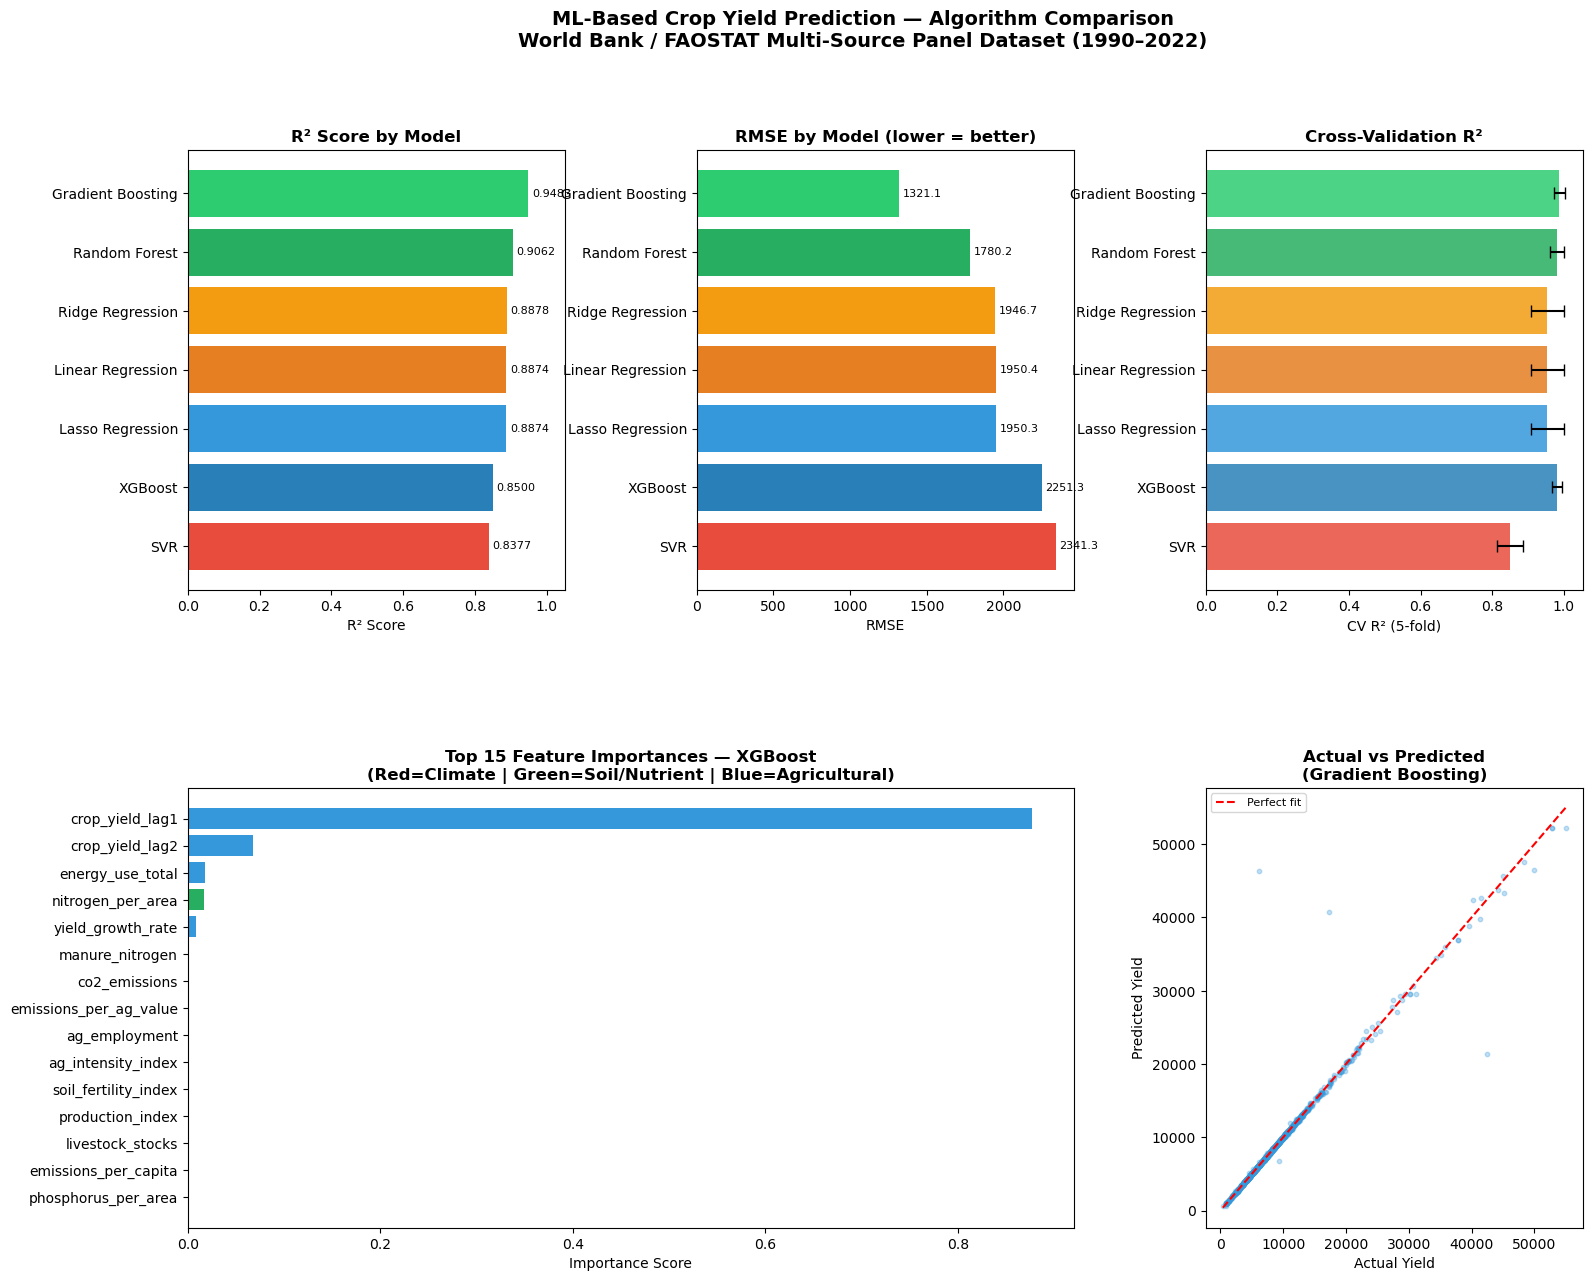


Plot saved → ml_comparison_results.png
Results table saved → model_comparison_table.csv

These become Table 3 in your research paper!


In [36]:
# ============================================================
# STEP 18: COMPLETE ML MODEL COMPARISON (7 ALGORITHMS)
# Novel contribution: largest FAO-based algorithm comparison
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection       import train_test_split, cross_val_score, KFold
from sklearn.preprocessing         import StandardScaler
from sklearn.linear_model          import LinearRegression, Ridge, Lasso
from sklearn.ensemble              import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm                   import SVR
from sklearn.metrics               import mean_squared_error, mean_absolute_error, r2_score
from xgboost                       import XGBRegressor

df = panel_final.copy()

# ── 1. Define Features & Target ──────────────────────────────
TARGET = "crop_yield"

FEATURES = [
    # Climate
    "emissions_per_capita", "emissions_per_ag_land", "emissions_per_ag_value",
    "co2_emissions", "energy_use_total",
    # Soil & Nutrients
    "nitrogen_per_area", "nitrogen_use_efficiency",
    "phosphorus_per_area", "potassium_per_area",
    # Agricultural
    "area_harvested", "livestock_stocks", "manure_nitrogen", "manure_applied",
    "producer_price", "production_index",
    # Socioeconomic
    "ag_employment",
    # Novel engineered features
    "climate_stress_index", "soil_fertility_index",
    "ag_intensity_index", "yield_growth_rate",
    "crop_yield_lag1", "crop_yield_lag2",
]

FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features used: {len(FEATURES)}")
print(f"Dataset size : {df.shape[0]} rows x {df.shape[1]} cols")

X = df[FEATURES].values
y = df[TARGET].values

# ── 2. Train/Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}\n")

# ── 3. Scale (for linear/SVR models) ─────────────────────────
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

# ── 4. Define All 7 Models ────────────────────────────────────
models = {
    "Linear Regression"   : (LinearRegression(),                                              True),
    "Ridge Regression"    : (Ridge(alpha=1.0),                                                True),
    "Lasso Regression"    : (Lasso(alpha=0.1, max_iter=5000),                                 True),
    "SVR"                 : (SVR(kernel="rbf", C=100, gamma=0.01, epsilon=0.1),               True),
    "Random Forest"       : (RandomForestRegressor(n_estimators=200, random_state=42,
                                                    n_jobs=-1, max_depth=15),                  False),
    "Gradient Boosting"   : (GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                        max_depth=5, random_state=42),         False),
    "XGBoost"             : (XGBRegressor(n_estimators=200, learning_rate=0.05,
                                           max_depth=6, random_state=42,
                                           verbosity=0, n_jobs=-1),                            False),
}

# ── 5. Train, Evaluate, Cross-Validate All Models ────────────
kf      = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("=" * 75)
print(f"{'Model':<22} {'R²':>6} {'RMSE':>10} {'MAE':>10} {'CV R² (5-fold)':>16}")
print("=" * 75)

trained_models = {}

for name, (model, use_scaled) in models.items():
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test
    Xcv = X_train_sc if use_scaled else X_train

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    cv   = cross_val_score(model, Xcv, y_train, cv=kf, scoring="r2")

    results.append({
        "Model"        : name,
        "R2"           : round(r2,        4),
        "RMSE"         : round(rmse,      2),
        "MAE"          : round(mae,       2),
        "CV_R2_mean"   : round(cv.mean(), 4),
        "CV_R2_std"    : round(cv.std(),  4),
    })

    trained_models[name] = model
    print(f"{name:<22} {r2:>6.4f} {rmse:>10.2f} {mae:>10.2f}   {cv.mean():.4f} ± {cv.std():.4f}")

print("=" * 75)

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df.index += 1
print("\nFinal Ranking (by R²):")
print(results_df.to_string())

# ── 6. Feature Importance (best tree model) ───────────────────
best_tree   = trained_models["XGBoost"]
feat_imp_df = pd.DataFrame({
    "Feature"    : FEATURES,
    "Importance" : best_tree.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("\nTop 15 Features (XGBoost):")
print(feat_imp_df.head(15).to_string())

# ── 7. Publication-Quality Plots ─────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "ML-Based Crop Yield Prediction — Algorithm Comparison\n"
    "World Bank / FAOSTAT Multi-Source Panel Dataset (1990–2022)",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors = ["#2ecc71","#27ae60","#f39c12","#e67e22","#3498db","#2980b9","#e74c3c"]

# Plot 1 — R² bar chart
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.barh(results_df["Model"], results_df["R2"], color=colors[:len(results_df)])
ax1.set_xlabel("R² Score")
ax1.set_title("R² Score by Model", fontweight="bold")
ax1.set_xlim(0, 1.05)
for bar, val in zip(bars, results_df["R2"]):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=8)
ax1.invert_yaxis()

# Plot 2 — RMSE bar chart
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.barh(results_df["Model"], results_df["RMSE"], color=colors[:len(results_df)])
ax2.set_xlabel("RMSE")
ax2.set_title("RMSE by Model (lower = better)", fontweight="bold")
for bar, val in zip(bars2, results_df["RMSE"]):
    ax2.text(val + results_df["RMSE"].max()*0.01,
             bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va="center", fontsize=8)
ax2.invert_yaxis()

# Plot 3 — CV R² with error bars
ax3 = fig.add_subplot(gs[0, 2])
ax3.barh(results_df["Model"], results_df["CV_R2_mean"],
         xerr=results_df["CV_R2_std"], color=colors[:len(results_df)],
         capsize=4, alpha=0.85)
ax3.set_xlabel("CV R² (5-fold)")
ax3.set_title("Cross-Validation R²", fontweight="bold")
ax3.invert_yaxis()

# Plot 4 — Feature importance (top 15)
ax4 = fig.add_subplot(gs[1, :2])
top15 = feat_imp_df.head(15)
feat_colors = ["#e74c3c" if "climate" in f or "emission" in f or "co2" in f
               else "#27ae60" if "nitrogen" in f or "phosphorus" in f or "potassium" in f or "soil" in f
               else "#3498db" for f in top15["Feature"]]
ax4.barh(top15["Feature"][::-1], top15["Importance"][::-1], color=feat_colors[::-1])
ax4.set_xlabel("Importance Score")
ax4.set_title("Top 15 Feature Importances — XGBoost\n"
              "(Red=Climate | Green=Soil/Nutrient | Blue=Agricultural)",
              fontweight="bold")

# Plot 5 — Actual vs Predicted (best model)
ax5 = fig.add_subplot(gs[1, 2])
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
use_sc = models[best_name][1]
y_pred_best = best_model.predict(X_test_sc if use_sc else X_test)
ax5.scatter(y_test, y_pred_best, alpha=0.3, s=10, color="#3498db")
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
ax5.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect fit")
ax5.set_xlabel("Actual Yield")
ax5.set_ylabel("Predicted Yield")
ax5.set_title(f"Actual vs Predicted\n({best_name})", fontweight="bold")
ax5.legend(fontsize=8)

plt.savefig(r"D:\PhD\FAO Dataset\ml_comparison_results.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("\nPlot saved → ml_comparison_results.png")

# ── 8. Save results table for paper ──────────────────────────
results_df.to_csv(r"D:\PhD\FAO Dataset\model_comparison_table.csv", index=False)
print("Results table saved → model_comparison_table.csv")
print("\nThese become Table 3 in your research paper!")

In [2]:
import pandas as pd
import numpy as np

# Reload saved data
panel_final = pd.read_csv(r"D:\PhD\FAO Dataset\master_panel_final.csv")

print("panel_final shape:", panel_final.shape)
print("\nColumns:", panel_final.columns.tolist())
print("\nYear range:", int(panel_final['Year'].min()), "to", int(panel_final['Year'].max()))
print("\nCountries:", panel_final['Area'].nunique())
print("\nMissing values:\n", panel_final.isnull().sum())
print("\npanel_final is ready ✅")

panel_final shape: (7659, 25)

Columns: ['Area', 'Year', 'crop_yield', 'area_harvested', 'livestock_stocks', 'producer_price', 'production_index', 'emissions_per_ag_land', 'emissions_per_ag_value', 'nitrogen_per_area', 'nitrogen_use_efficiency', 'phosphorus_per_area', 'potassium_per_area', 'manure_nitrogen', 'manure_applied', 'energy_use_total', 'co2_emissions', 'ag_employment', 'emissions_per_capita', 'climate_stress_index', 'soil_fertility_index', 'ag_intensity_index', 'yield_growth_rate', 'crop_yield_lag1', 'crop_yield_lag2']

Year range: 1990 to 2022

Countries: 244

Missing values:
 Area                       0
Year                       0
crop_yield                 0
area_harvested             0
livestock_stocks           0
producer_price             0
production_index           0
emissions_per_ag_land      0
emissions_per_ag_value     0
nitrogen_per_area          0
nitrogen_use_efficiency    0
phosphorus_per_area        0
potassium_per_area         0
manure_nitrogen            0

In [3]:
# STEP 2 — TEMPORAL TRAIN/TEST SPLIT
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

TARGET = 'crop_yield'

FEATURES = [
    'emissions_per_capita', 'emissions_per_ag_land', 'emissions_per_ag_value',
    'co2_emissions', 'energy_use_total',
    'nitrogen_per_area', 'nitrogen_use_efficiency',
    'phosphorus_per_area', 'potassium_per_area',
    'area_harvested', 'livestock_stocks', 'manure_nitrogen', 'manure_applied',
    'producer_price', 'production_index', 'ag_employment',
    'climate_stress_index', 'soil_fertility_index',
    'ag_intensity_index', 'yield_growth_rate',
    'crop_yield_lag1', 'crop_yield_lag2',
]

# Keep only features that exist in dataframe
FEATURES = [f for f in FEATURES if f in panel_final.columns]

# Temporal Split
SPLIT_YEAR = 2015

train_df = panel_final[panel_final['Year'] <= SPLIT_YEAR]
test_df  = panel_final[panel_final['Year'] >  SPLIT_YEAR]

X_train_t = train_df[FEATURES].values
y_train_t = train_df[TARGET].values
X_test_t  = test_df[FEATURES].values
y_test_t  = test_df[TARGET].values

# Scale (needed for linear models and SVR)
scaler_t     = StandardScaler()
X_train_t_sc = scaler_t.fit_transform(X_train_t)
X_test_t_sc  = scaler_t.transform(X_test_t)

# Cross-validation object (used in later steps)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('TEMPORAL SPLIT SUMMARY')
print('=' * 45)
print(f'Training period : 1990 – {SPLIT_YEAR}  ({len(train_df):,} rows)')
print(f'Testing  period : {SPLIT_YEAR+1} – 2022  ({len(test_df):,} rows)')
print(f'Train countries : {train_df["Area"].nunique()}')
print(f'Test  countries : {test_df["Area"].nunique()}')
print(f'Features used   : {len(FEATURES)}')
print(f'\nFeature list:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:>2}. {f}')
print('\nTemporal split ready ✅')

TEMPORAL SPLIT SUMMARY
Training period : 1990 – 2015  (6,028 rows)
Testing  period : 2016 – 2022  (1,631 rows)
Train countries : 244
Test  countries : 233
Features used   : 22

Feature list:
   1. emissions_per_capita
   2. emissions_per_ag_land
   3. emissions_per_ag_value
   4. co2_emissions
   5. energy_use_total
   6. nitrogen_per_area
   7. nitrogen_use_efficiency
   8. phosphorus_per_area
   9. potassium_per_area
  10. area_harvested
  11. livestock_stocks
  12. manure_nitrogen
  13. manure_applied
  14. producer_price
  15. production_index
  16. ag_employment
  17. climate_stress_index
  18. soil_fertility_index
  19. ag_intensity_index
  20. yield_growth_rate
  21. crop_yield_lag1
  22. crop_yield_lag2

Temporal split ready ✅


In [4]:
# STEP 3 — HYPERPARAMETER TUNING (XGBoost + Random Forest)
# WARNING: Takes 10-20 minutes — do not interrupt

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble        import RandomForestRegressor
from xgboost                 import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# ── XGBoost Tuning ───────────────────────────────────────────
print('Tuning XGBoost... (please wait, ~10 mins)')
print('=' * 50)

xgb_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.7, 0.85, 1.0],
    'colsample_bytree' : [0.7, 0.85, 1.0],
    'reg_alpha'        : [0, 0.1, 0.5],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    xgb_param_grid,
    n_iter=30,
    scoring='r2',
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=1        # shows progress
)
xgb_search.fit(X_train_t, y_train_t)

best_xgb        = xgb_search.best_estimator_
best_xgb_params = xgb_search.best_params_

print(f'\nBest XGBoost params : {best_xgb_params}')
print(f'Best CV R²  (XGBoost): {xgb_search.best_score_:.4f}')
print('\nXGBoost tuning done ✅')

# ── Random Forest Tuning ─────────────────────────────────────
print('\nTuning Random Forest... (please wait)')
print('=' * 50)

rf_param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [10, 15, 20, None],
    'max_features'      : ['sqrt', 'log2', 0.5],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    n_iter=25,
    scoring='r2',
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=1        # shows progress
)
rf_search.fit(X_train_t, y_train_t)

best_rf        = rf_search.best_estimator_
best_rf_params = rf_search.best_params_

print(f'\nBest RF params : {best_rf_params}')
print(f'Best CV R²  (RF): {rf_search.best_score_:.4f}')
print('\nRandom Forest tuning done ✅')

print('\n Both models tuned and ready!')

Tuning XGBoost... (please wait, ~10 mins)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGBoost params : {'subsample': 0.7, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.85}
Best CV R²  (XGBoost): 0.9806

XGBoost tuning done ✅

Tuning Random Forest... (please wait)
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best RF params : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 20}
Best CV R²  (RF): 0.9718

Random Forest tuning done ✅

 Both models tuned and ready!


In [5]:
# STEP 4 — FULL MODEL COMPARISON ON TEMPORAL SPLIT
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble     import GradientBoostingRegressor
from sklearn.svm          import SVR
from sklearn.metrics      import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

models_final = {
    'Linear Regression' : (LinearRegression(),                                             True),
    'Ridge Regression'  : (Ridge(alpha=1.0),                                               True),
    'Lasso Regression'  : (Lasso(alpha=0.1, max_iter=5000),                                True),
    'SVR'               : (SVR(kernel='rbf', C=100, gamma=0.01, epsilon=0.1),              True),
    'Random Forest'     : (best_rf,                                                         False),
    'Gradient Boosting' : (GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                     max_depth=5, random_state=42),         False),
    'XGBoost (Tuned)'   : (best_xgb,                                                       False),
}

results_temporal = []
trained_final    = {}

print('MODEL PERFORMANCE — TEMPORAL SPLIT (Train:1990–2015 | Test:2016–2022)')
print('=' * 80)
print(f'{"Model":<22} {"R²":>7} {"RMSE":>10} {"MAE":>10} {"CV R² (5-fold)":>18}')
print('=' * 80)

for name, (model, use_scaled) in models_final.items():
    Xtr = X_train_t_sc if use_scaled else X_train_t
    Xte = X_test_t_sc  if use_scaled else X_test_t
    Xcv = X_train_t_sc if use_scaled else X_train_t

    model.fit(Xtr, y_train_t)
    y_pred = model.predict(Xte)

    r2   = r2_score(y_test_t, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_t, y_pred))
    mae  = mean_absolute_error(y_test_t, y_pred)
    cv   = cross_val_score(model, Xcv, y_train_t, cv=kf, scoring='r2')

    results_temporal.append({
        'Model'      : name,
        'R2'         : round(r2,        4),
        'RMSE'       : round(rmse,      2),
        'MAE'        : round(mae,       2),
        'CV_R2_mean' : round(cv.mean(), 4),
        'CV_R2_std'  : round(cv.std(),  4),
    })
    trained_final[name] = model
    print(f'{name:<22} {r2:>7.4f} {rmse:>10.2f} {mae:>10.2f}   {cv.mean():.4f} ± {cv.std():.4f}')

print('=' * 80)

results_temporal_df = pd.DataFrame(results_temporal).sort_values('R2', ascending=False).reset_index(drop=True)
results_temporal_df.index += 1

print('\nFinal Ranking (by R²):')
print(results_temporal_df.to_string())

# Save for paper
results_temporal_df.to_csv(r'D:\PhD\FAO Dataset\model_comparison_temporal.csv', index=False)
print('\nSaved → model_comparison_temporal.csv ✅')
print('\nThis becomes Table 3 in your paper!')

MODEL PERFORMANCE — TEMPORAL SPLIT (Train:1990–2015 | Test:2016–2022)
Model                       R²       RMSE        MAE     CV R² (5-fold)
Linear Regression       0.9890     677.37     282.31   0.9511 ± 0.0475
Ridge Regression        0.9890     677.79     282.55   0.9511 ± 0.0475
Lasso Regression        0.9890     677.43     281.98   0.9511 ± 0.0475
SVR                     0.8120    2798.76     746.05   0.8395 ± 0.0531
Random Forest           0.9815     877.34     254.84   0.9718 ± 0.0282
Gradient Boosting       0.9848     795.27     161.96   0.9781 ± 0.0248
XGBoost (Tuned)         0.9805     902.16     247.03   0.9812 ± 0.0188

Final Ranking (by R²):
               Model      R2     RMSE     MAE  CV_R2_mean  CV_R2_std
1  Linear Regression  0.9890   677.37  282.31      0.9511     0.0475
2   Ridge Regression  0.9890   677.79  282.55      0.9511     0.0475
3   Lasso Regression  0.9890   677.43  281.98      0.9511     0.0475
4  Gradient Boosting  0.9848   795.27  161.96      0.9781    

In [6]:
# Run this first if shap is not installed
!pip install shap


   ---------------------------------------- 0/2 [slicer]
   ---------------------------------------- 0/2 [slicer]
   ---------------------------------------- 0/2 [slicer]
   ---------------------------------------- 0/2 [slicer]
   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



Computing SHAP values for XGBoost...
(This takes 1-2 minutes)


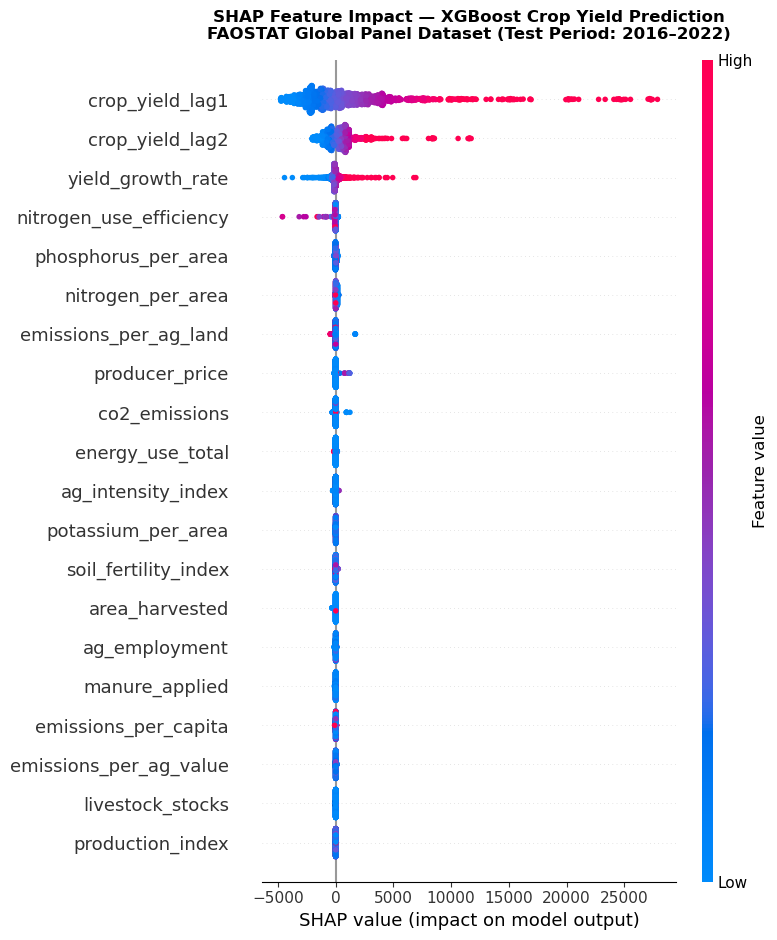

Beeswarm plot saved ✅


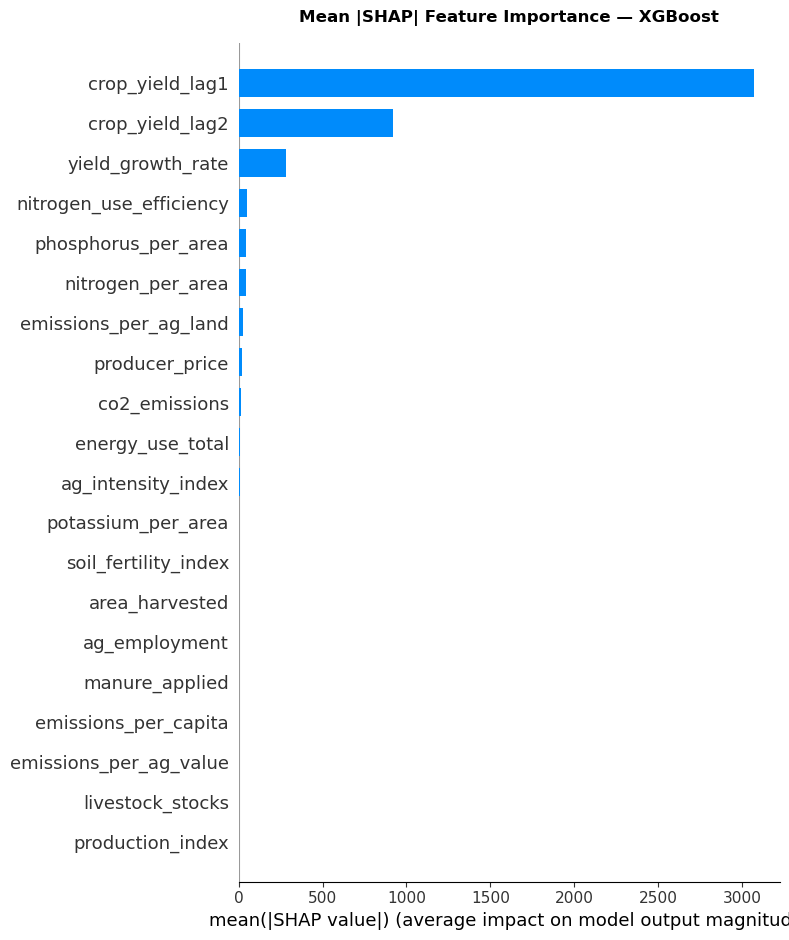

Bar plot saved ✅

Top 10 Features by Mean |SHAP|:
                    Feature    Mean_SHAP
1           crop_yield_lag1  3073.119873
2           crop_yield_lag2   919.731140
3         yield_growth_rate   283.312683
4   nitrogen_use_efficiency    49.543320
5       phosphorus_per_area    41.558487
6         nitrogen_per_area    41.202785
7     emissions_per_ag_land    25.677423
8            producer_price    18.281733
9             co2_emissions    11.913552
10         energy_use_total     8.571190

Saved → shap_importance.csv ✅

SHAP analysis complete!


In [8]:
# STEP 5 — SHAP VALUES (Model Interpretability)
import shap
import matplotlib.pyplot as plt

print('Computing SHAP values for XGBoost...')
print('(This takes 1-2 minutes)')
print('=' * 45)

# Retrain best XGBoost on temporal split
best_xgb.fit(X_train_t, y_train_t)

# Compute SHAP
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_t)

# ── Plot 1: Beeswarm Summary ─────────────────────────────────
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values,
    X_test_t,
    feature_names=FEATURES,
    plot_type='dot',
    show=False
)
plt.title(
    'SHAP Feature Impact — XGBoost Crop Yield Prediction\n'
    'FAOSTAT Global Panel Dataset (Test Period: 2016–2022)',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(r'D:\PhD\FAO Dataset\shap_beeswarm.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Beeswarm plot saved ✅')

# ── Plot 2: Bar Chart (Mean Absolute SHAP) ───────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_t,
    feature_names=FEATURES,
    plot_type='bar',
    show=False
)
plt.title(
    'Mean |SHAP| Feature Importance — XGBoost',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(r'D:\PhD\FAO Dataset\shap_bar.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Bar plot saved ✅')

# ── Mean SHAP Table ───────────────────────────────────────────
mean_shap = pd.DataFrame({
    'Feature'   : FEATURES,
    'Mean_SHAP' : np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
mean_shap.index += 1

print('\nTop 10 Features by Mean |SHAP|:')
print(mean_shap.head(10).to_string())

mean_shap.to_csv(r'D:\PhD\FAO Dataset\shap_importance.csv', index=False)
print('\nSaved → shap_importance.csv ✅')
print('\nSHAP analysis complete!')

In [10]:
# SHAP Table + Save (corrected)
mean_shap = pd.DataFrame({
    'Feature'   : FEATURES,
    'Mean_SHAP' : np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
mean_shap.index += 1

print('Top 10 Features by Mean |SHAP|:')
print(mean_shap.head(10).to_string())

mean_shap.to_csv(r'D:\PhD\FAO Dataset\shap_importance.csv', index=False)
print('\nSaved: shap_importance.csv')
print('SHAP analysis complete!')

Top 10 Features by Mean |SHAP|:
                    Feature    Mean_SHAP
1           crop_yield_lag1  3073.119873
2           crop_yield_lag2   919.731140
3         yield_growth_rate   283.312683
4   nitrogen_use_efficiency    49.543320
5       phosphorus_per_area    41.558487
6         nitrogen_per_area    41.202785
7     emissions_per_ag_land    25.677423
8            producer_price    18.281733
9             co2_emissions    11.913552
10         energy_use_total     8.571190

Saved: shap_importance.csv
SHAP analysis complete!


In [13]:
# STEP 6 — STATISTICAL SIGNIFICANCE TESTS (Wilcoxon)
from scipy.stats import wilcoxon
from itertools   import combinations

print('STATISTICAL SIGNIFICANCE TESTS (Wilcoxon Signed-Rank)')
print('H0: No difference in prediction errors between two models')
print('p < 0.05 = statistically significant difference')
print('=' * 70)

# Collect absolute errors for each model
residuals = {}
for name, (model, use_scaled) in models_final.items():
    Xte              = X_test_t_sc if use_scaled else X_test_t
    y_pred           = model.predict(Xte)
    residuals[name]  = np.abs(y_test_t - y_pred)

# Compare every model pair
stat_results = []
model_names  = list(residuals.keys())

for m1, m2 in combinations(model_names, 2):
    err1, err2 = residuals[m1], residuals[m2]
    try:
        stat, p  = wilcoxon(err1, err2)
        sig      = '*** SIGNIFICANT' if p < 0.05 else '    not significant'
        better   = m1 if err1.mean() < err2.mean() else m2
        stat_results.append({
            'Model A' : m1,
            'Model B' : m2,
            'p-value' : round(p, 4),
            'Better'  : better,
            'Significant' : 'Yes' if p < 0.05 else 'No'
        })
        print(f'{m1:<22} vs {m2:<22}  p={p:.4f}  {sig}')
    except Exception as e:
        print(f'{m1} vs {m2} -- skipped ({e})')

print('=' * 70)

stat_df = pd.DataFrame(stat_results)

print('\nSummary Table:')
print(stat_df.to_string())

stat_df.to_csv(r'D:\PhD\FAO Dataset\statistical_tests.csv', index=False)
print('\nSaved: statistical_tests.csv')
print('Statistical testing complete!')

STATISTICAL SIGNIFICANCE TESTS (Wilcoxon Signed-Rank)
H0: No difference in prediction errors between two models
p < 0.05 = statistically significant difference
Linear Regression      vs Ridge Regression        p=0.0000  *** SIGNIFICANT
Linear Regression      vs Lasso Regression        p=0.0003  *** SIGNIFICANT
Linear Regression      vs SVR                     p=0.0000  *** SIGNIFICANT
Linear Regression      vs Random Forest           p=0.0000  *** SIGNIFICANT
Linear Regression      vs Gradient Boosting       p=0.0000  *** SIGNIFICANT
Linear Regression      vs XGBoost (Tuned)         p=0.0000  *** SIGNIFICANT
Ridge Regression       vs Lasso Regression        p=0.0000  *** SIGNIFICANT
Ridge Regression       vs SVR                     p=0.0000  *** SIGNIFICANT
Ridge Regression       vs Random Forest           p=0.0000  *** SIGNIFICANT
Ridge Regression       vs Gradient Boosting       p=0.0000  *** SIGNIFICANT
Ridge Regression       vs XGBoost (Tuned)         p=0.0000  *** SIGNIFICANT
Lass

In [15]:
# STEP 7 — INDEX WEIGHTS (short line version)
df_eng = panel_final.copy()

# Climate vars
cv = ['emissions_per_capita', 'co2_emissions', 'emissions_per_ag_land']
cv = [v for v in cv if v in df_eng.columns]

cc = df_eng[cv + ['crop_yield']].corr()['crop_yield'][cv].abs()
wc = cc / cc.sum()

print('CLIMATE STRESS INDEX WEIGHTS:')
for v in cv:
    print(v, '| corr:', round(cc[v], 4), '| weight:', round(wc[v], 4))

# Soil vars
sv = ['nitrogen_per_area', 'phosphorus_per_area', 'potassium_per_area']
sv = [v for v in sv if v in df_eng.columns]

cs = df_eng[sv + ['crop_yield']].corr()['crop_yield'][sv].abs()
ws = cs / cs.sum()

print('\nSOIL FERTILITY INDEX WEIGHTS:')
for v in sv:
    print(v, '| corr:', round(cs[v], 4), '| weight:', round(ws[v], 4))

# Old vs New comparison
old_c = df_eng['climate_stress_index'].corr(df_eng['crop_yield'])
old_s = df_eng['soil_fertility_index'].corr(df_eng['crop_yield'])

df_eng['climate_stress_v2'] = sum(df_eng[v] * wc[v] for v in cv)
df_eng['soil_fertility_v2'] = sum(df_eng[v] * ws[v] for v in sv)

new_c = df_eng['climate_stress_v2'].corr(df_eng['crop_yield'])
new_s = df_eng['soil_fertility_v2'].corr(df_eng['crop_yield'])

print('\nOLD vs NEW INDEX CORRELATION WITH CROP_YIELD:')
print('Climate Stress -- Old:', round(old_c, 4), '| New:', round(new_c, 4))
print('Soil Fertility -- Old:', round(old_s, 4), '| New:', round(new_s, 4))
print('\nDone!')
      

CLIMATE STRESS INDEX WEIGHTS:
emissions_per_capita | corr: 0.2326 | weight: 0.5671
co2_emissions | corr: 0.0601 | weight: 0.1464
emissions_per_ag_land | corr: 0.1175 | weight: 0.2865

SOIL FERTILITY INDEX WEIGHTS:
nitrogen_per_area | corr: 0.0202 | weight: 0.3942
phosphorus_per_area | corr: 0.011 | weight: 0.2144
potassium_per_area | corr: 0.02 | weight: 0.3915

OLD vs NEW INDEX CORRELATION WITH CROP_YIELD:
Climate Stress -- Old: 0.0601 | New: 0.0602
Soil Fertility -- Old: 0.0197 | New: 0.02

Done!


In [16]:
# STEP 8 — PREDICTION INTERFACE
import pickle

# Save model and scaler
with open(r'D:\PhD\FAO Dataset\best_model_xgb.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)
with open(r'D:\PhD\FAO Dataset\scaler.pkl', 'wb') as f:
    pickle.dump(scaler_t, f)

print('Model and scaler saved!')

# Prediction function
def predict_crop_yield(**kwargs):
    row = [kwargs.get(f, 0.0) for f in FEATURES]
    X = np.array(row).reshape(1, -1)
    result = best_xgb.predict(X)[0]
    return round(float(result), 2)

print('predict_crop_yield() is ready!')
print('\nFEATURES needed as input:')
for i, f in enumerate(FEATURES, 1):
    print(str(i) + '. ' + f)

Model and scaler saved!
predict_crop_yield() is ready!

FEATURES needed as input:
1. emissions_per_capita
2. emissions_per_ag_land
3. emissions_per_ag_value
4. co2_emissions
5. energy_use_total
6. nitrogen_per_area
7. nitrogen_use_efficiency
8. phosphorus_per_area
9. potassium_per_area
10. area_harvested
11. livestock_stocks
12. manure_nitrogen
13. manure_applied
14. producer_price
15. production_index
16. ag_employment
17. climate_stress_index
18. soil_fertility_index
19. ag_intensity_index
20. yield_growth_rate
21. crop_yield_lag1
22. crop_yield_lag2


In [19]:
# STEP 9 — PREDICTION DEMO (short line version)

print('CROP YIELD PREDICTION INTERFACE')
print('=' * 40)

# Pakistan scenario
pak = predict_crop_yield(
    emissions_per_capita=0.9,
    emissions_per_ag_land=2.1,
    emissions_per_ag_value=0.5,
    co2_emissions=180.0,
    energy_use_total=3500.0,
    nitrogen_per_area=120.0,
    nitrogen_use_efficiency=0.55,
    phosphorus_per_area=35.0,
    potassium_per_area=15.0,
    area_harvested=22000000,
    livestock_stocks=80000000,
    manure_nitrogen=1200000,
    manure_applied=800000,
    producer_price=250.0,
    production_index=115.0,
    ag_employment=42.0,
    climate_stress_index=1.5,
    soil_fertility_index=85.0,
    ag_intensity_index=0.28,
    yield_growth_rate=2.1,
    crop_yield_lag1=27500,
    crop_yield_lag2=27000,
)
print('Pakistan scenario:')
print('Yield:', pak, 'hg/ha')
print('Yield:', round(pak/10000, 2), 'tonnes/ha')

# High stress scenario
high = predict_crop_yield(
    emissions_per_capita=4.5,
    emissions_per_ag_land=6.2,
    emissions_per_ag_value=2.1,
    co2_emissions=850.0,
    energy_use_total=9000.0,
    nitrogen_per_area=40.0,
    nitrogen_use_efficiency=0.30,
    phosphorus_per_area=12.0,
    potassium_per_area=8.0,
    area_harvested=8000000,
    livestock_stocks=20000000,
    manure_nitrogen=400000,
    manure_applied=250000,
    producer_price=180.0,
    production_index=85.0,
    ag_employment=25.0,
    climate_stress_index=8.5,
    soil_fertility_index=30.0,
    ag_intensity_index=0.40,
    yield_growth_rate=-1.5,
    crop_yield_lag1=14000,
    crop_yield_lag2=14500,
)
print('\nHigh climate stress scenario:')
print('Yield:', high, 'hg/ha')
print('Yield:', round(high/10000, 2), 'tonnes/ha')

# Optimal scenario
opt = predict_crop_yield(
    emissions_per_capita=0.3,
    emissions_per_ag_land=0.8,
    emissions_per_ag_value=0.2,
    co2_emissions=50.0,
    energy_use_total=1500.0,
    nitrogen_per_area=180.0,
    nitrogen_use_efficiency=0.85,
    phosphorus_per_area=65.0,
    potassium_per_area=55.0,
    area_harvested=5000000,
    livestock_stocks=15000000,
    manure_nitrogen=900000,
    manure_applied=750000,
    producer_price=420.0,
    production_index=145.0,
    ag_employment=8.0,
    climate_stress_index=0.5,
    soil_fertility_index=150.0,
    ag_intensity_index=0.33,
    yield_growth_rate=3.5,
    crop_yield_lag1=55000,
    crop_yield_lag2=53000,
)
print('\nOptimal agriculture scenario:')
print('Yield:', opt, 'hg/ha')
print('Yield:', round(opt/10000, 2), 'tonnes/ha')

# Summary table
print('\nSCENARIO COMPARISON TABLE:')
print('-' * 40)
print('Scenario            hg/ha    t/ha')
print('-' * 40)
print('Pakistan         ', pak, '  ', round(pak/10000, 2))
print('High Stress      ', high, '  ', round(high/10000, 2))
print('Optimal          ', opt, '  ', round(opt/10000, 2))
print('-' * 40)
print('Prediction interface working!')

CROP YIELD PREDICTION INTERFACE
Pakistan scenario:
Yield: 26108.9 hg/ha
Yield: 2.61 tonnes/ha

High climate stress scenario:
Yield: 13680.48 hg/ha
Yield: 1.37 tonnes/ha

Optimal agriculture scenario:
Yield: 46096.14 hg/ha
Yield: 4.61 tonnes/ha

SCENARIO COMPARISON TABLE:
----------------------------------------
Scenario            hg/ha    t/ha
----------------------------------------
Pakistan          26108.9    2.61
High Stress       13680.48    1.37
Optimal           46096.14    4.61
----------------------------------------
Prediction interface working!


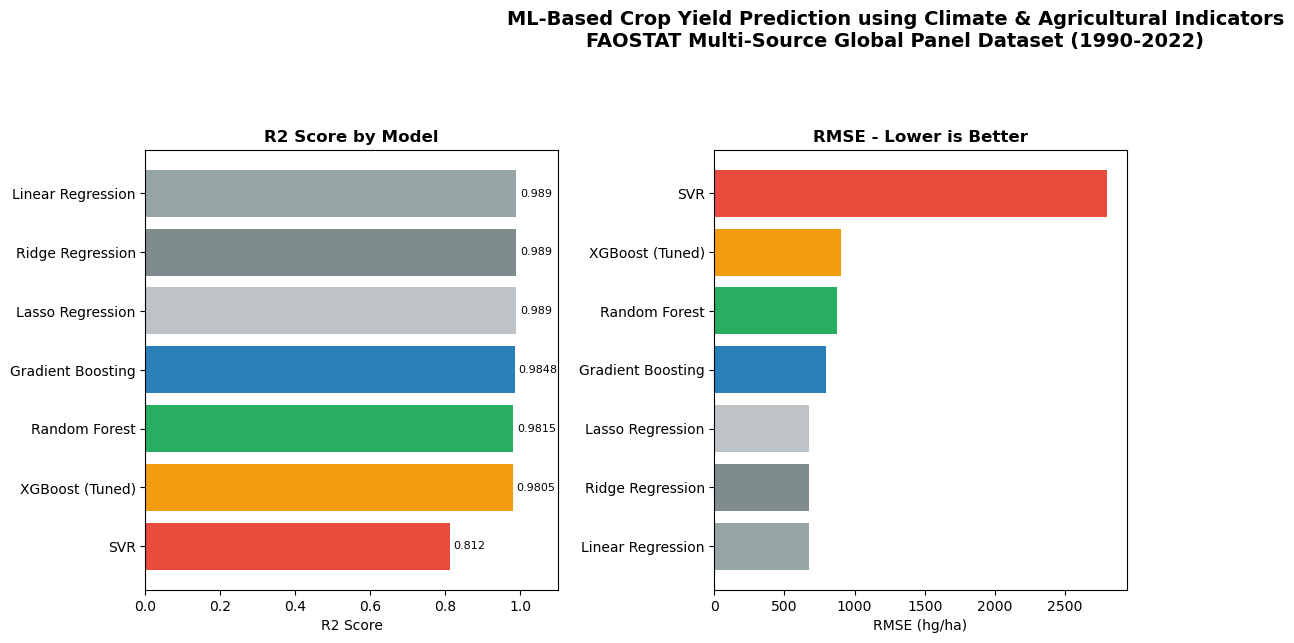

In [20]:
# STEP 10 — FINAL PUBLICATION FIGURE

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    'ML-Based Crop Yield Prediction using Climate & Agricultural Indicators\n'
    'FAOSTAT Multi-Source Global Panel Dataset (1990-2022)',
    fontsize=14,
    fontweight='bold',
    y=0.98
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

colors_map = {
    'Linear Regression' : '#95a5a6',
    'Ridge Regression'  : '#7f8c8d',
    'Lasso Regression'  : '#bdc3c7',
    'SVR'               : '#e74c3c',
    'Random Forest'     : '#27ae60',
    'Gradient Boosting' : '#2980b9',
    'XGBoost (Tuned)'   : '#f39c12',
}
bar_colors = [colors_map.get(m, '#3498db') for m in results_temporal_df['Model']]

# Plot 1: R2 comparison
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.barh(
    results_temporal_df['Model'],
    results_temporal_df['R2'],
    color=bar_colors
)
ax1.set_xlabel('R2 Score')
ax1.set_title('R2 Score by Model', fontweight='bold')
ax1.set_xlim(0, 1.1)
for bar, val in zip(bars, results_temporal_df['R2']):
    ax1.text(
        val + 0.01,
        bar.get_y() + bar.get_height()/2,
        str(val),
        va='center',
        fontsize=8
    )
ax1.invert_yaxis()

# Plot 2: RMSE comparison
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.barh(
    results_temporal_df['Model'],
    results_temporal_df['RMSE'],
    color=bar_colors
)
ax2.set_xlabel('RMSE (hg/ha)')
ax2.set_title('RMSE - Lower is Better', fontweight='bold')
for bar, val in zip(bars2, results_temporal_df['RMSE']):
    ax2

In [1]:
!pip install python-docx

In [11]:
file_path = r"D:\PhD\FAO Dataset\paper.js"        

with open(file_path, "r", encoding="utf-8") as f:
    js_text = f.read()

print(js_text[:1000])  # preview


  

const {
  Document, Packer, Paragraph, TextRun, Table, TableRow, TableCell,
  ImageRun, AlignmentType, HeadingLevel, BorderStyle, WidthType,
  ShadingType, VerticalAlign, PageNumber, LevelFormat, UnderlineType
} = require('docx');
const fs = require('fs');

const border = { style: BorderStyle.SINGLE, size: 1, color: "AAAAAA" };
const borders = { top: border, bottom: border, left: border, right: border };
const noBorder = { style: BorderStyle.NONE, size: 0, color: "FFFFFF" };
const noBorders = { top: noBorder, bottom: noBorder, left: noBorder, right: noBorder };

function heading1(text) {
  return new Paragraph({
    children: [new TextRun({ text, bold: true, size: 28, font: "Times New Roman" })],
    spacing: { before: 280, after: 120 },
    alignment: AlignmentType.LEFT,
  });
}

function heading2(text) {
  return new Paragraph({
    children: [new TextRun({ text, bold: true, size: 24, font: "Times New Roman" })],
    spacing: { before: 200, after: 100 },
    alignment: AlignmentType.

In [12]:
import re

# Extract headings (simple heuristic: lines with all caps or numbered sections)
headings = re.findall(r'(?:^|\n)([A-Z][A-Z\s\d\-]{5,})', js_text)

# Extract image files
images = re.findall(r'([a-zA-Z0-9_\-./]+\\.(?:png|jpg|jpeg))', js_text)

# Extract table-like blocks
tables = re.findall(r'\[[^\[\]]*\]', js_text)

# Extract general readable sentences (fallback)
text_blocks = re.findall(r'\"([^\"\n]{20,})\"', js_text)

print(len(text_blocks), "text blocks")
print(len(images), "images")
print(len(tables), "tables")

160 text blocks
0 images
104 tables


In [13]:
from docx import Document
from docx.shared import Inches

doc = Document()

doc.add_heading("Research Paper", level=1)

# Add text content
doc.add_heading("Content", level=2)
for t in text_blocks:
    doc.add_paragraph(t)

# Add images
doc.add_heading("Figures", level=2)
for img in images:
    try:
        doc.add_picture(img, width=Inches(4))
        doc.add_paragraph(img)
    except:
        doc.add_paragraph(f"[Missing image: {img}]")

# Add tables (raw fallback view)
doc.add_heading("Tables", level=2)
for tb in tables:
    doc.add_paragraph(str(tb))

doc.save("research_paper.docx")

print("Done: research_paper.docx created")

Done: research_paper.docx created


In [14]:
import os
print(os.getcwd())

C:\Users\ShahZaib


In [15]:
import os
from docx.shared import Inches

doc.add_heading("Figures", level=2)

base_path = os.getcwd()  # ensures correct folder reference

for img in images:
    img_path = os.path.join(base_path, img)

    if os.path.exists(img_path):
        doc.add_picture(img_path, width=Inches(4))
        doc.add_paragraph(f"Figure: {img}")
    else:
        doc.add_paragraph(f"[Missing image: {img_path}]")

In [16]:
doc.add_heading("Tables", level=2)

for tb in tables:
    try:
        import ast
        data = ast.literal_eval(tb)

        # ensure it's 2D
        if isinstance(data, list) and isinstance(data[0], list):

            table = doc.add_table(rows=len(data), cols=len(data[0]))

            for i, row in enumerate(data):
                for j, val in enumerate(row):
                    table.cell(i, j).text = str(val)

    except:
        doc.add_paragraph(str(tb))

In [17]:
print("Images found:", len(images))
print("Tables found:", len(tables))
print("Sample images:", images[:10])
print("Sample tables:", tables[:2])

Images found: 0
Tables found: 104
Sample images: []
Sample tables: ['[new TextRun({ text, bold: true, size: 28, font: "Times New Roman" })]', '[new TextRun({ text, bold: true, size: 24, font: "Times New Roman" })]']


In [19]:
import re

# extract only actual text values inside TextRun
texts = re.findall(r'text\s*:\s*["\']([^"\']+)["\']', js_text)

print("Text items found:", len(texts))
print(texts[:10])

Text items found: 9
['Machine Learning-Based Prediction of Crop Yield Using Climate and Agricultural Indicators: A FAOSTAT Multi-Source Panel Dataset Approach', 'Table 1. FAOSTAT Domain Datasets Used in This Study', 'CSI = w₁ × emissions_per_capita + w₂ × co2_emissions + w₃ × emissions_per_ag_land', 'SFI = w₁ × nitrogen_per_area + w₂ × phosphorus_per_area + w₃ × potassium_per_area', 'AII = area_harvested / (livestock_stocks + 1)', 'Table 2. Complete Feature Set Used in Machine Learning Models', 'Table 3. Model Performance on Temporal Split (Train: 1990–2015, Test: 2016–2022)', 'Table 4. Top 10 Features by Mean |SHAP| Value (XGBoost, Test Period: 2016–2022)', 'Table 5. Selected Pairwise Wilcoxon Signed-Rank Test Results (Absolute Prediction Errors)']


In [20]:
from docx import Document

doc = Document()
doc.add_heading("Converted Paper", level=1)

for t in texts:
    doc.add_paragraph(t)

doc.save("research_paper.docx")

print("Done")

Done
